# 1. Project Title
Title: Spatial Analysis of Accessibility Improvement: The Utsunomiya LRT in Japan

# 2. Team members
Shotaro Ichikawa (A69036086), Kota Sando (A69035449), Mitsuru Watanabe (A69036536)

<font color='red'>Note: the code has been modified to directly run on AGOL</font>

# 3. Our Research Question, Why it is Important

Japan’s regional cities are facing population decline, population aging, and continued migration toward major metropolitan areas such as Tokyo and Osaka. At the same time, cities like Utsunomiya have historically been highly car-dependent, creating challenges for sustainable urban development and mobility. A major concern in Utsunomiya was poor public transportation access between the city center and the eastern industrial zones, where thousands of workers commute daily and road congestion is severe. To address these issues, the city introduced a Light Rail Transit (LRT) system in 2023 as part of its compact-city strategy. This analysis is needed to evaluate whether the LRT has successfully improved public transportation accessibility and supported broader urban and transportation policy goals.

Previous studies have demonstrated that LRT systems can improve urban mobility and have been successfully implemented in many cities worldwide. In particular, prior research on Utsunomiya suggested that combining LRT with other transportation modes, such as buses, could provide an efficient alternative to automobile travel. However, much of the existing literature focuses on the general benefits of LRT implementation rather than quantitatively measuring how accessibility changes after system deployment. There remains limited evidence on the spatial extent of accessibility improvements for commuters, especially in relation to industrial employment centers and working-age populations. As a result, the actual accessibility benefits experienced by residents following the opening of the Utsunomiya LRT remain insufficiently evaluated.

This study addresses that gap by examining how much the Utsunomiya LRT improved public transportation accessibility to the Kiyohara Industrial Park after its 2023 opening. Using a multimodal transportation network and GIS-based accessibility analysis, the study compares 30-minute and 60-minute travel-time catchment areas before and after the LRT introduction. In addition to measuring changes in accessible area coverage, the analysis evaluates changes in the number of working-age residents who can reach the industrial zone within those travel times. By quantifying accessibility gains, the study seeks to assess the effectiveness of the LRT investment, provide evidence for future transit planning and potential network extensions, and offer a transferable evaluation framework for other regional Japanese cities considering similar transit-oriented development strategies.

# 4. Background and literature

Estimating the societal benefit of LRT is complex and nonlinear. Past literature has looked at housing rent price and population data to approximate the true benefit of LRT.

In 2008, Boucq and Papon (2008) showed that accessibility improvements from the T2 light rail project in France were capitalized into housing prices by about 3%, while Papon et al. (2015) found no significant impact on real estate prices for the T3 line in Paris. In 2010, Pacheco-Raguz (2010) analyzed the impacts of LRT in Manila using GIS accessibility, land prices, land use, and population density data, and found that the impacts were limited.


- Boucq, Elise, and Francis Papon. (2008). Assessment of the Real Estate Benefits Due to Accessibility Gains Brought by a Transport Project: The Impacts of a Light Rail Infrastructure Improvement in the Hauts-de-Seine Department. https://www.researchgate.net/publication/227580297_Assessment_of_the_Real_Estate_Benefits_Due_to_Accessibility_Gains_Brought_by_a_Transport_Project_The_Impacts_of_a_Light_Rail_Infrastructure_Improvement_in_the_Hauts-de-Seine_Department.
- Papon, Francis, Dany Nguyen-Luong, and Elise Boucq. (2015). Should Any New Light Rail Line Provide Real Estate Gains, or Not? The Case of the T3 Line in Paris. Research in Transportation Economics 49: 43–54. https://www.sciencedirect.com/science/article/pii/S0739885915000062?via%3Dihub.
- Pacheco-Raguz, Javier F. (2010). Assessing the Impacts of Light Rail Transit on Urban Land in Manila. Journal of Transport and Land Use 3, no. 1. https://jtlu.org/index.php/jtlu/article/view/13.  



We build up our analysis from Sato (2018) who researched on the cost benefit analysis of LRT Development prior to its debut. Sato found that building the LRT is expected to encourage people to live closer to public transportation corridors. Adding feeder buses makes the system more accessible, attracts more residents, and provides greater economic benefits than building the LRT alone. Therefore, the study concludes that integrating feeder buses with the LRT is the more effective strategy for supporting urban development and improving transportation in Utsunomiya.

- Sato, T., Sasaki, T., & Chikuma, M. (2018). Cost–benefit analysis of developing a light rail transit and feeder bus system in Utsunomiya City considering the change in population distribution. Asian Transport Studies, 5(1), 151–164.
https://www.jstage.jst.go.jp/article/eastsats/5/1/5_151/_pdf/-char/en.

Our analysis focus on the accessibility solely by public transportation, cruicial for elderly people and children, because we believe the mobility development and mitigated traffic congestion must be evaluated in terms of travel time and efficiency, rather than housing rent and downtown population.

## Disclosure of AI use

All materials described here (code, texts, source links, etc.) are written and proofread by us. However, we used generative AI (ChatGPT, Gemini, Claude, Cursor) to brainstorm ideas, generate research guidelines and conduct preliminary analysis.

# 5. Python libraries or ArcGIS modules used

This project mainly used GeoPandas, Shapely, and NetworkX for spatial and transportation network analysis. GeoPandas was used to load, manage, clip, merge, and spatially join GIS datasets, including roads, railways, bus stops, administrative boundaries, and population mesh data. Shapely was used for geometric operations such as buffering, dissolving, snapping, and polygon construction. NetworkX was used to build multimodal transportation networks and compute shortest-path travel times for accessibility analysis. Pandas and NumPy were used for data processing and numerical calculations, while Matplotlib was used to create maps and visualizations.

Libraries
- geopandas: Read, manage, and analyze GIS shapefiles.
- shapely:	Geometric operations on points, lines, and spatial features.
- networkx:	Build transportation networks and compute shortest paths.
- pandas: Tabular data processing and attribute table manipulation.
- numpy:	Numerical calculations and array operations.
- matplotlib:	Create maps, figures, legends, and visualizations.

Compared with the project proposal, the package selection became more focused on network-based accessibility analysis. We originally considered Rasterio, rioxarray, OSMnx, Folium, and Scikit-learn. However, these were not required because the population dataset was provided as polygon mesh data rather than raster data, and the project ultimately focused on multimodal accessibility modeling rather than machine learning or land-price prediction.

In [ ]:
# ============================================================
# Import libraries and global settings
# ============================================================

## The most important settings are:
## - Input and output directories
## - Analysis CRS
## - Origin stop name
## - Network buffer size
## - Travel-time thresholds
## - Walking, bus, and rail speeds
## - Waiting time and transfer penalty assumptions
## - Densification intervals for road, bus, and rail networks
## - Snapping tolerances for connecting points to networks

## These parameters are defined at the beginning so that the model assumptions can be easily reviewed and modified.


from pathlib import Path
import warnings
import math

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString
from shapely.ops import nearest_points

import networkx as nx

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# Directory settings
# ------------------------------------------------------------
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./output/pre_lrt_multimodal")

ADMIN_DIR = DATA_DIR / "Admin"
BUS_ROUTE_DIR = DATA_DIR / "BusRoute"
BUS_STOP_DIR = DATA_DIR / "BusStop"
LRT_STOP_DIR = DATA_DIR / "LRTstop"
ROAD_DIR = DATA_DIR / "Road"
TRAIN_DIR = DATA_DIR / "Train"

FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
GPKG_DIR = OUTPUT_DIR / "gpkg"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, GPKG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CRS settings
# ------------------------------------------------------------
CRS_WGS84 = "EPSG:4326"

# Coordinate reference system used by the post-LRT map team
CRS_ANALYSIS = "EPSG:6678"

# ------------------------------------------------------------
# Core model parameters
# ------------------------------------------------------------
TARGET_LRT_STOP_NAME = "清原地区市民センター前"

# Network calculation area:
# Do NOT clip to Utsunomiya + Haga for network calculation.
# Instead, use a wide buffer from the origin.
NETWORK_BUFFER_M = 50000  # 50 km

TIME_LIMITS = [30, 60]

# Walking speed: 80 m/min = 4.8 km/h
WALK_SPEED_M_PER_MIN = 80

# Bus speed: 18 km/h = 300 m/min
BUS_SPEED_M_PER_MIN = 300

# Team decision: no waiting time for the simple model
BUS_WAIT_TIME_MIN = 0

# Transfer penalty kept as parameter for future extension
TRANSFER_PENALTY_MIN = 0

# Densification settings
ROAD_DENSIFY_INTERVAL_M = 150
BUS_ROUTE_DENSIFY_INTERVAL_M = 100

# Snapping tolerances
BUS_STOP_TO_ROAD_SNAP_TOLERANCE_M = 200
BUS_STOP_TO_BUS_ROUTE_SNAP_TOLERANCE_M = 200
ORIGIN_TO_ROAD_SNAP_TOLERANCE_M = 500

# Output polygon corridor width
# This converts reachable road-line networks into visible polygons.
ISOCHRONE_CORRIDOR_BUFFER_M = 25

# 6. Data Sources

This study used several spatial datasets to construct a multimodal accessibility model for the Utsunomiya area and to estimate the population affected by the introduction of the LRT system.

- Administrative Boundary Data from GADM
Used to define municipal boundaries and create map visualizations.
https://gadm.org/   

- Bus Route Data (N07) from National Land Numerical Information (NLNI)  
Used to construct the feeder-bus transportation network.<br>
https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N07.html  

- Bus Stop Data (P11) from National Land Numerical Information (NLNI)  
Used to identify bus stop locations and operators throughout the study area.
https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-P11.html   

- Utsunomiya Light Rail Stop Data<br>Stop location data were obtained from a GTFS (General Transit Feed Specification) dataset published on GitHub and converted from the original stops.txt file into a shapefile for GIS analysis. The dataset was used to represent the post-LRT network and estimate accessibility improvements after the opening of the Utsunomiya-Haga LRT.
https://github.com/magn01ia/Haga-Utsunomiya-LRT-GTFS/blob/main/stops.txt

- Road Data (N13) from National Land Numerical Information (NLNI)  
Used to build the road-based walking network and transfer connections between transportation modes.
https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N13-2024.html   

- Railroad and Station Data (N05) from National Land Numerical Information (NLNI)  
Used to obtain railway station locations and conventional railway route geometries.
https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N05-2025.html

- Projected Population Data by 250 meter Mesh from National Land Numerical Information (NLNI)
Used to estimate total population and working-age population coverage before and after LRT implementation.
https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-mesh250r6.html

Compared with the project proposal, the final dataset selection became more focused on accessibility analysis. We originally considered station passenger statistics, official land price data, and road traffic data to evaluate broader economic and land-use impacts. However, the final analysis concentrated on transportation accessibility and population coverage, making these datasets unnecessary.

The main limitation of the study is that the transportation network was constructed from spatial infrastructure data rather than actual service schedules. Bus, rail, and LRT travel were represented using assumed travel speeds and average waiting times. More detailed and precise data, such as GTFS, including service frequency, operating schedules, transfer coordination, and direction-specific operations, would be helpful for the analysis. However, a complete and reliable timetable-based dataset covering bus, rail, and LRT services in the study area was not available from official public sources, limiting the ability to model actual service schedules and transfer times.

## Data Description

### Administrative Boundary Data from GADM

| Item | Description |
|---|---|
| File names | gadm41_JPN_0.shp, gadm41_JPN_1.shp, gadm41_JPN_2.shp |
| Coverage | Japan nationwide; administrative levels 0, 1, and 2 |
| Year | 2018 |
| CRS | EPSG:4326 / WGS 84 |
| Source | GADM |
| URL | https://gadm.org/ |
| Geometry | Polygon administrative boundaries |

Used to define municipal boundaries and create map visualizations.

---

### Bus Route Data (N07) from National Land Numerical Information (NLNI)

| Item | Description |
|---|---|
| File name | N07-22_09.shp |
| Identifier | N07 |
| Coverage | Tochigi Prefecture |
| Geometry | Line |
| Source | National Land Numerical Information (NLNI) |
| URL | https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N07.html |

Used to construct the feeder-bus transportation network.

---

### Bus Stop Data (P11) from National Land Numerical Information (NLNI)

| Item | Description |
|---|---|
| File name | P11-22_09.shp |
| Identifier | P11 |
| Coverage | Tochigi Prefecture |
| Geometry | Point / GM_Point |
| Year | 2022 (Reiwa 4) |
| Source | National Land Numerical Information (NLNI) |
| URL | https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-P11.html |

Used to identify bus stop locations and operators throughout the study area.

---

### Utsunomiya Light Rail Stop Data

| Item | Description |
|---|---|
| File name | lrt_stops.shp (converted from GTFS stops.txt) |
| Coverage | Utsunomiya–Haga LRT corridor |
| Geometry | Point |
| Source | GTFS dataset published on GitHub |
| URL | https://github.com/magn01ia/Haga-Utsunomiya-LRT-GTFS/blob/main/stops.txt |

Stop location data were obtained from a GTFS (General Transit Feed Specification) dataset published on GitHub and converted from the original stops.txt file into a shapefile for GIS analysis. The dataset was used to represent the post-LRT network and estimate accessibility improvements after the opening of the Utsunomiya–Haga LRT.

---

### Road Data (N13) from National Land Numerical Information (NLNI)

| Item | Description |
|---|---|
| File names | N13-24_5439.shp, N13-24_5440.shp, N13-24_5539.shp, N13-24_5540.shp |
| Coverage | Utsunomiya and surrounding municipalities |
| Geometry | Line / GM_Curve |
| Date field | N13_001 |
| Source | National Land Numerical Information (NLNI) |
| URL | https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N13-2024.html |

Used to build the road-based walking network and transfer connections between transportation modes.

---

### Railroad and Station Data (N05) from National Land Numerical Information (NLNI)

| Item | Description |
|---|---|
| File names | N05-25_RailroadSection2.shp, N05-25_Station2.shp |
| Identifier | N05 |
| Coverage | Nationwide railway lines and stations |
| Geometry | Railway sections: Line / GM_Curve; Stations: Point / GM_Point |
| Source | National Land Numerical Information (NLNI) |
| URL | https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N05-2025.html |

Used to obtain railway station locations and conventional railway route geometries.

---

### Projected Population Data by 250 m Mesh from National Land Numerical Information (NLNI)

| Item | Description |
|---|---|
| Identifier / File name | 250m_mesh_2024_09.shp |
| Coverage | Tochigi Prefecture |
| Geometry | Polygon / GM_Surface |
| Base year | 2020 |
| Projection years | 2025–2070 (5-year intervals) |
| Estimate version | 2024 (R6 National Land Policy Bureau estimate) |
| Source | National Land Numerical Information (NLNI) |
| URL | https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-mesh250r6.html |

Used to estimate total population and working-age population coverage before and after LRT implementation.

## File Structure
The notebook assumes the following file structure:

```text
./data
├── Admin
│   └── gadm41_JPN_2.shp
├── BusRoute
│   └── N07-22_09.shp
├── BusStop
│   └── P11-22_09.shp
├── LRTstop
│   └── lrt_stops.shp
├── Population
│   └── 250m_mesh_2024_09.shp
├── Road
│   ├── N13-24_5439.shp
│   ├── N13-24_5440.shp
│   ├── N13-24_5539.shp
│   └── N13-24_5540.shp
└── Train
    ├── N05-25_RailroadSection2.shp
    └── N05-25_Station2.shp

./output/pre_lrt_multimodal
├── figures
├── tables
└── gpkg

Shapefiles require all related sidecar files, especially .shp, .shx, .dbf, and .prj. If a .prj file is missing, the notebook assigns the documented source CRS before reprojecting to the analysis CRS.

The road network is loaded from all shapefiles in ./data/Road/ and combined into one GeoDataFrame. This is necessary because a single N13 road tile does not cover the entire 50 km network analysis area.

In [ ]:
# ============================================================
# Define file paths
# ============================================================

## The road dataset is handled differently from the other layers.
## Instead of specifying a single road shapefile, the notebook loads all road shapefiles stored in `./data/Road/` and combines them.
## This is necessary because the network calculation area is larger than a single N13 road tile.

ADMIN_PATH = ADMIN_DIR / "gadm41_JPN_2.shp"

BUS_ROUTE_PATH = BUS_ROUTE_DIR / "N07-22_09.shp"
BUS_STOP_PATH = BUS_STOP_DIR / "P11-22_09.shp"

LRT_STOP_PATH = LRT_STOP_DIR / "lrt_stops.shp"

# Road data:
# Instead of specifying one shapefile, we will load all .shp files
# in ./data/Road/ and combine them.
# ROAD_PATH is no longer used.
ROAD_SHAPEFILE_DIR = ROAD_DIR

RAIL_ROUTE_PATH = TRAIN_DIR / "N05-25_RailroadSection2.shp"
RAIL_STOP_PATH = TRAIN_DIR / "N05-25_Station2.shp"

paths = {
    "admin": ADMIN_PATH,
    "bus_routes": BUS_ROUTE_PATH,
    "bus_stops": BUS_STOP_PATH,
    "lrt_stops": LRT_STOP_PATH,
    "road_dir": ROAD_SHAPEFILE_DIR,
    "rail_routes": RAIL_ROUTE_PATH,
    "rail_stops": RAIL_STOP_PATH,
}

for name, path in paths.items():
    print(f"{name:12s}: {path} | exists = {path.exists()}")

admin       : data/Admin/gadm41_JPN_2.shp | exists = True
bus_routes  : data/BusRoute/N07-22_09.shp | exists = True
bus_stops   : data/BusStop/P11-22_09.shp | exists = True
lrt_stops   : data/LRTstop/lrt_stops.shp | exists = True
road_dir    : data/Road | exists = True
rail_routes : data/Train/N05-25_RailroadSection2.shp | exists = True
rail_stops  : data/Train/N05-25_Station2.shp | exists = True


# 7. Data Cleaning

We cleaned and prepared several spatial datasets before building the accessibility model. Shapefiles were loaded using multiple Japanese encodings, including UTF-8, CP932, and Shift-JIS, to correctly read Japanese stop and station names. All layers were reprojected to EPSG:6678, a meter-based CRS used for distance and travel-time calculations. We removed records with missing geometry and created unique IDs for bus stops and railway stations.

For network construction, complex line features were converted into simple line segments, and additional points were added along roads, bus routes, railways, and LRT lines at regular intervals. This made it possible to build a connected transportation network and calculate travel times more accurately. We also checked the distance between bus stops or railway stations and the nearest transportation network connection points to ensure that they were properly connected to the network.

These needs were identified through both metadata review and direct inspection of geometry types, CRS, feature counts, and diagnostic outputs. The cleaning effort was greater than expected because multimodal network construction required more preparation than simple spatial overlay.

## Helper Function Definition

In [ ]:
# ============================================================
# Helper functions
# ============================================================

## This cell defines reusable helper functions used throughout the notebook.

## The functions perform the following tasks:
## - Read shapefiles robustly with Japanese encodings
## - Explode MultiLineString geometries into individual LineStrings
## - Densify LineStrings by adding vertices at regular intervals
## - Convert line geometries into NetworkX graph nodes and edges
## - Convert graph nodes back into GeoDataFrames
## - Connect point features, such as bus stops and railway stations, to the nearest network node

## These helper functions keep the later analysis cells shorter and easier to read.

def read_shp(path, target_crs=CRS_ANALYSIS, default_crs=CRS_WGS84):
    """
    Read a shapefile and reproject it to target_crs.
    Tries common Japanese encodings.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    encodings = ["utf-8", "cp932", "shift_jis"]
    last_error = None


    for enc in encodings:
        try:
            gdf = gpd.read_file(path, encoding=enc)
            print(f"Loaded {path.name} with encoding: {enc}")
            break
        except Exception as e:
            last_error = e
    else:
        raise last_error

    if gdf.crs is None:
        print(f"WARNING: {path.name} has no CRS. Assuming {default_crs}.")
        gdf = gdf.set_crs(default_crs, allow_override=True)

    if target_crs is not None:
        gdf = gdf.to_crs(target_crs)

    gdf = gdf[~gdf.geometry.isna()].copy()

    return gdf


def explode_lines(gdf):
    """
    Explode MultiLineString geometries into LineStrings.
    """
    exploded = gdf.explode(index_parts=False).reset_index(drop=True)
    exploded = exploded[exploded.geometry.geom_type == "LineString"].copy()
    return exploded


def densify_linestring(line, interval_m=100):
    """
    Densify a LineString by adding vertices at a fixed interval.
    """
    if line.length == 0:
        return line

    if line.length <= interval_m:
        return line

    distances = list(np.arange(0, line.length, interval_m))
    if distances[-1] != line.length:
        distances.append(line.length)

    points = [line.interpolate(d) for d in distances]

    clean_points = []
    for p in points:
        if len(clean_points) == 0 or not p.equals(clean_points[-1]):
            clean_points.append(p)

    if len(clean_points) < 2:
        return line

    return LineString(clean_points)


def node_id_from_xy(prefix, x, y, precision=1):
    """
    Create a stable node ID from rounded coordinates.
    """
    return f"{prefix}_{round(x, precision)}_{round(y, precision)}"


def add_lines_to_graph(
    G,
    lines_gdf,
    node_prefix,
    edge_type,
    speed_m_per_min,
    route_id_col=None
):
    """
    Add LineString geometries to a NetworkX graph.
    Consecutive vertices become directed edges in both directions.

    This function is compatible with nx.DiGraph().
    Road, bus route, and rail route movements are assumed to be available
    in both directions in this simplified model.
    """
    for idx, row in lines_gdf.iterrows():
        line = row.geometry
        coords = list(line.coords)

        route_id = row[route_id_col] if route_id_col is not None and route_id_col in row else idx

        for i in range(len(coords) - 1):
            x1, y1 = coords[i]
            x2, y2 = coords[i + 1]

            n1 = node_id_from_xy(node_prefix, x1, y1)
            n2 = node_id_from_xy(node_prefix, x2, y2)

            p1 = Point(x1, y1)
            p2 = Point(x2, y2)

            distance_m = p1.distance(p2)

            if distance_m == 0:
                continue

            travel_time_min = distance_m / speed_m_per_min

            if not G.has_node(n1):
                G.add_node(
                    n1,
                    node_type=node_prefix,
                    geometry=p1
                )

            if not G.has_node(n2):
                G.add_node(
                    n2,
                    node_type=node_prefix,
                    geometry=p2
                )

            edge_geom_forward = LineString([p1, p2])
            edge_geom_reverse = LineString([p2, p1])

            # Forward edge
            G.add_edge(
                n1,
                n2,
                weight=travel_time_min,
                distance_m=distance_m,
                edge_type=edge_type,
                geometry=edge_geom_forward,
                route_id=route_id
            )

            # Reverse edge
            G.add_edge(
                n2,
                n1,
                weight=travel_time_min,
                distance_m=distance_m,
                edge_type=edge_type,
                geometry=edge_geom_reverse,
                route_id=route_id
            )

    return G


def graph_nodes_to_gdf(G, node_type_filter=None):
    """
    Convert graph nodes to a GeoDataFrame.
    """
    records = []

    for node_id, attrs in G.nodes(data=True):
        if node_type_filter is not None and attrs.get("node_type") != node_type_filter:
            continue

        records.append({
            "node_id": node_id,
            "node_type": attrs.get("node_type"),
            "geometry": attrs.get("geometry")
        })

    return gpd.GeoDataFrame(records, geometry="geometry", crs=CRS_ANALYSIS)


def connect_points_to_nearest_nodes(
    G,
    points_gdf,
    target_nodes_gdf,
    point_id_col,
    point_node_type,
    edge_type,
    speed_m_per_min,
    snap_tolerance_m,
    connection_weight_override=None
):
    """
    Add point nodes and connect them to nearest existing network nodes.

    This function is designed for walking-type connector edges, such as:
    - origin <-> road
    - bus stop <-> road
    - rail station <-> road

    Because the main graph is now a directed graph, this function adds
    connector edges in both directions with the same walking cost.

    Do NOT use this function for boarding/alighting connections between:
    - bus stop and bus route
    - rail station and rail route

    Those should use connect_points_to_route_nodes_asymmetric().
    """

    points_gdf = points_gdf.copy()
    target_nodes_gdf = target_nodes_gdf.copy()

    # ------------------------------------------------------------
    # Clean spatial join helper columns from previous operations
    # ------------------------------------------------------------
    join_helper_cols = [
        "index_right",
        "index_left",
        "index_right0",
        "index_left0",
        "snap_dist_m",
        "target_node_id"
    ]

    points_gdf = points_gdf.drop(
        columns=[c for c in join_helper_cols if c in points_gdf.columns],
        errors="ignore"
    )

    target_nodes_gdf = target_nodes_gdf.drop(
        columns=[c for c in join_helper_cols if c in target_nodes_gdf.columns],
        errors="ignore"
    )

    # ------------------------------------------------------------
    # Prepare target nodes with a non-conflicting ID column
    # ------------------------------------------------------------
    target_nodes_for_join = target_nodes_gdf[["node_id", "geometry"]].copy()
    target_nodes_for_join = target_nodes_for_join.rename(
        columns={"node_id": "target_node_id"}
    )

    # ------------------------------------------------------------
    # Nearest spatial join
    # ------------------------------------------------------------
    joined = gpd.sjoin_nearest(
        points_gdf,
        target_nodes_for_join,
        how="left",
        distance_col="snap_dist_m"
    )

    joined = joined.drop_duplicates(subset=[point_id_col]).copy()
    joined["is_snapped"] = joined["snap_dist_m"] <= snap_tolerance_m

    snapped = joined[joined["is_snapped"]].copy()

    # For faster lookup of target geometry
    target_geom_lookup = target_nodes_gdf.set_index("node_id").geometry

    # ------------------------------------------------------------
    # Add point nodes and bidirectional connector edges
    # ------------------------------------------------------------
    for idx, row in snapped.iterrows():
        point_node_id = row[point_id_col]
        target_node_id = row["target_node_id"]
        snap_dist_m = row["snap_dist_m"]

        point_geom = row.geometry
        target_geom = target_geom_lookup.loc[target_node_id]

        G.add_node(
            point_node_id,
            node_type=point_node_type,
            geometry=point_geom
        )

        if connection_weight_override is None:
            weight = snap_dist_m / speed_m_per_min
        else:
            weight = connection_weight_override

        # Forward connector: point -> network node
        G.add_edge(
            point_node_id,
            target_node_id,
            weight=weight,
            distance_m=snap_dist_m,
            edge_type=edge_type,
            geometry=LineString([point_geom, target_geom])
        )

        # Reverse connector: network node -> point
        G.add_edge(
            target_node_id,
            point_node_id,
            weight=weight,
            distance_m=snap_dist_m,
            edge_type=edge_type,
            geometry=LineString([target_geom, point_geom])
        )

    return G, joined, snapped

def connect_points_to_route_nodes_asymmetric(
    G,
    points_gdf,
    target_nodes_gdf,
    point_id_col,
    point_node_type,
    board_edge_type,
    alight_edge_type,
    snap_tolerance_m,
    boarding_wait_time_min,
    transfer_penalty_min=0
):
    """
    Connect point nodes, such as bus stops or railway stations, to route nodes
    with asymmetric directed edges.

    point -> route:
        boarding edge with waiting-time penalty

    route -> point:
        alighting edge with zero waiting-time penalty

    This is used for:
    - bus_stop -> bus_route
    - rail_station -> rail_route
    """

    points_gdf = points_gdf.copy()
    target_nodes_gdf = target_nodes_gdf.copy()

    join_helper_cols = [
        "index_right",
        "index_left",
        "index_right0",
        "index_left0",
        "snap_dist_m",
        "target_node_id"
    ]

    points_gdf = points_gdf.drop(
        columns=[c for c in join_helper_cols if c in points_gdf.columns],
        errors="ignore"
    )

    target_nodes_gdf = target_nodes_gdf.drop(
        columns=[c for c in join_helper_cols if c in target_nodes_gdf.columns],
        errors="ignore"
    )

    target_nodes_for_join = target_nodes_gdf[["node_id", "geometry"]].copy()
    target_nodes_for_join = target_nodes_for_join.rename(
        columns={"node_id": "target_node_id"}
    )

    joined = gpd.sjoin_nearest(
        points_gdf,
        target_nodes_for_join,
        how="left",
        distance_col="snap_dist_m"
    )

    joined = joined.drop_duplicates(subset=[point_id_col]).copy()
    joined["is_snapped"] = joined["snap_dist_m"] <= snap_tolerance_m

    snapped = joined[joined["is_snapped"]].copy()

    target_geom_lookup = target_nodes_gdf.set_index("node_id").geometry

    for idx, row in snapped.iterrows():
        point_node_id = row[point_id_col]
        target_node_id = row["target_node_id"]
        snap_dist_m = row["snap_dist_m"]

        point_geom = row.geometry
        target_geom = target_geom_lookup.loc[target_node_id]

        G.add_node(
            point_node_id,
            node_type=point_node_type,
            geometry=point_geom
        )

        # Boarding: point -> route node
        # Add waiting time only when entering the route network.
        board_weight = boarding_wait_time_min + transfer_penalty_min

        G.add_edge(
            point_node_id,
            target_node_id,
            weight=board_weight,
            distance_m=snap_dist_m,
            edge_type=board_edge_type,
            geometry=LineString([point_geom, target_geom]),
            wait_time_min=boarding_wait_time_min,
            transfer_penalty_min=transfer_penalty_min
        )

        # Alighting: route node -> point
        # No waiting time when getting off.
        G.add_edge(
            target_node_id,
            point_node_id,
            weight=0,
            distance_m=snap_dist_m,
            edge_type=alight_edge_type,
            geometry=LineString([target_geom, point_geom]),
            wait_time_min=0,
            transfer_penalty_min=0
        )

    return G, joined, snapped

## Coordinate Reference System

All spatial layers are reprojected to: `EPSG:6678`

This CRS is used because it is a meter-based projected coordinate system suitable for distance and travel-time calculations in this study area. Final outputs can be reprojected to EPSG:4326 if needed for web mapping or sharing.

In [ ]:
# ============================================================
# Load data
# ============================================================

## The road layer is created by reading and combining all road shapefiles in `./data/Road/`.
## Each road feature is also assigned a `source_file` attribute so that we can later check which road tiles are used.

## All datasets are reprojected to the analysis CRS, EPSG:6678.

admin = read_shp(ADMIN_PATH)
bus_routes = read_shp(BUS_ROUTE_PATH)
bus_stops = read_shp(BUS_STOP_PATH)
lrt_stops = read_shp(LRT_STOP_PATH)
rail_routes = read_shp(RAIL_ROUTE_PATH)
rail_stops = read_shp(RAIL_STOP_PATH)

# ------------------------------------------------------------
# Load and combine all road shapefiles in ./data/Road/
# ------------------------------------------------------------

road_paths = sorted(ROAD_SHAPEFILE_DIR.glob("*.shp"))

print("Road shapefiles found:")
for p in road_paths:
    print(" -", p.name)

if len(road_paths) == 0:
    raise FileNotFoundError(f"No road shapefiles found in {ROAD_SHAPEFILE_DIR}")

road_gdfs = []

for p in road_paths:
    gdf = read_shp(p)
    gdf["source_file"] = p.name
    road_gdfs.append(gdf)

roads = pd.concat(road_gdfs, ignore_index=True)
roads = gpd.GeoDataFrame(roads, geometry="geometry", crs=CRS_ANALYSIS)

print("\nCombined roads:", roads.shape)
print("Number of road source files:", roads["source_file"].nunique())
display(roads["source_file"].value_counts())

print("\nLayer summary:")
for name, gdf in {
    "admin": admin,
    "bus_routes": bus_routes,
    "bus_stops": bus_stops,
    "lrt_stops": lrt_stops,
    "roads": roads,
    "rail_routes": rail_routes,
    "rail_stops": rail_stops,
}.items():
    print(f"{name:12s}: {gdf.shape}, CRS={gdf.crs}, geom={gdf.geom_type.unique()}")

## The output confirms that all required datasets were successfully loaded and reprojected to the analysis CRS.

## For the road data, the number of source files should match the number of N13 road tiles placed in `./data/Road/`.
## In this version, four road tiles are expected: southwest, southeast, northwest, and northeast.
## This expanded road coverage is necessary to avoid artificial truncation of the road-based walking isochrone.

Loaded gadm41_JPN_2.shp with encoding: utf-8
Loaded N07-22_09.shp with encoding: cp932
Loaded P11-22_09.shp with encoding: cp932
Loaded lrt_stops.shp with encoding: utf-8
Loaded N05-25_RailroadSection2.shp with encoding: cp932
Loaded N05-25_Station2.shp with encoding: cp932
Road shapefiles found:
 - N13-24_5439.shp
 - N13-24_5440.shp
 - N13-24_5539.shp
 - N13-24_5540.shp
Loaded N13-24_5439.shp with encoding: utf-8
Loaded N13-24_5440.shp with encoding: utf-8
Loaded N13-24_5539.shp with encoding: utf-8
Loaded N13-24_5540.shp with encoding: utf-8

Combined roads: (2356200, 10)
Number of road source files: 4


source_file
N13-24_5439.shp    1267863
N13-24_5440.shp     613014
N13-24_5540.shp     348710
N13-24_5539.shp     126613
Name: count, dtype: int64


Layer summary:
admin       : (1811, 14), CRS=EPSG:6678, geom=['Polygon' 'MultiPolygon']
bus_routes  : (4629, 3), CRS=EPSG:6678, geom=['LineString']
bus_stops   : (3778, 74), CRS=EPSG:6678, geom=['Point']
lrt_stops   : (34, 11), CRS=EPSG:6678, geom=['Point']
roads       : (2356200, 10), CRS=EPSG:6678, geom=['LineString']
rail_routes : (2653, 12), CRS=EPSG:6678, geom=['LineString']
rail_stops  : (23864, 12), CRS=EPSG:6678, geom=['Point']


In [ ]:
# ============================================================
# Population mesh settings
# ============================================================

POP_DIR = DATA_DIR / "Population"

# Use 2025 as the closest post-LRT population estimate
POP_YEAR = 2025

TOTAL_POP_COL = f"PT00_{POP_YEAR}"   # total population
WORKING_POP_COL = f"PTB_{POP_YEAR}"  # age 15-64 population

print("Total population column:", TOTAL_POP_COL)
print("Working-age population column:", WORKING_POP_COL)

Total population column: PT00_2025
Working-age population column: PTB_2025


In [ ]:
# ============================================================
# Load Tochigi 250m population mesh
# ============================================================

# Search shapefiles under data/Population
pop_shp_candidates = list(POP_DIR.rglob("*.shp"))

print("Population shapefile candidates:")
for p in pop_shp_candidates:
    print(" -", p)

if len(pop_shp_candidates) == 0:
    raise FileNotFoundError("No population shapefile found under data/Population")

# If there is only Tochigi data, this should work.
POP_PATH = pop_shp_candidates[0]

pop_mesh = read_shp(POP_PATH)

print("Loaded population mesh:", pop_mesh.shape)
print("CRS:", pop_mesh.crs)
print("Columns sample:")
print(pop_mesh.columns.tolist()[:30])

display(pop_mesh.head())

Population shapefile candidates:
 - data/Population/250m_mesh_2024_09.shp
Loaded 250m_mesh_2024_09.shp with encoding: utf-8
Loaded population mesh: (34921, 344)
CRS: EPSG:6678
Columns sample:
['MESH_ID', 'SHICODE', 'PTN_2020', 'HITOKU2025', 'GASSAN2025', 'PTN_2025', 'PT00_2025', 'PT01_2025', 'PT02_2025', 'PT03_2025', 'PT04_2025', 'PT05_2025', 'PT06_2025', 'PT07_2025', 'PT08_2025', 'PT09_2025', 'PT10_2025', 'PT11_2025', 'PT12_2025', 'PT13_2025', 'PT14_2025', 'PT15_2025', 'PT16_2025', 'PT17_2025', 'PT18_2025', 'PT19_2025', 'PT20_2025', 'PTA_2025', 'PTB_2025', 'PTC_2025']


,MESH_ID,SHICODE,PTN_2020,HITOKU2025,GASSAN2025,PTN_2025,PT00_2025,PT01_2025,PT02_2025,PT03_2025,...,PTB_2070,PTC_2070,PTD_2070,PTE_2070,RTA_2070,RTB_2070,RTC_2070,RTD_2070,RTE_2070,geometry
0,5439254333,09203,7.0497,@,None,6.7583,8.4443,0.0000,0.000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"POLYGON ((-105282.789 -420423.088, -105279.998..."
1,5439254334,09203,2.0070,*,5439254333,1.6860,0.0000,0.0000,0.000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"POLYGON ((-105001.773 -420426.476, -104998.99 ..."
2,5439254524,09364,10.9386,None,None,10.5348,10.5348,0.0000,0.000,0.0000,...,0.0000,3.2795,1.1782,1.1782,0.0000,0.0000,1.0000,0.3593,0.3593,"POLYGON ((-102197.038 -420922.185, -102194.329..."
3,5439254542,09364,27.8467,None,None,26.2359,26.2359,0.2515,2.113,2.0097,...,6.6241,5.0445,2.9758,2.9758,0.0706,0.5276,0.4018,0.2370,0.2370,"POLYGON ((-102194.329 -420691.021, -102191.621..."
4,5439254544,09364,117.3023,None,None,112.8844,112.8844,3.7363,0.000,1.0169,...,25.0759,31.2242,22.2385,15.1013,0.0790,0.4102,0.5108,0.3638,0.2470,"POLYGON ((-102191.621 -420459.858, -102188.912..."


In [ ]:
# ============================================================
# Prepare Tochigi population mesh
# ============================================================

pop_mesh_tochigi = pop_mesh.copy()

POP_YEAR = 2025

TOTAL_POP_COL = f"PT00_{POP_YEAR}"   # total population
WORKING_POP_COL = f"PTB_{POP_YEAR}"  # age 15-64 population

# Check required columns
for col in [TOTAL_POP_COL, WORKING_POP_COL]:
    if col not in pop_mesh_tochigi.columns:
        raise ValueError(f"Required column not found: {col}")

# Replace missing values with 0
pop_mesh_tochigi[TOTAL_POP_COL] = pop_mesh_tochigi[TOTAL_POP_COL].fillna(0)
pop_mesh_tochigi[WORKING_POP_COL] = pop_mesh_tochigi[WORKING_POP_COL].fillna(0)

print("Population mesh ready:", pop_mesh_tochigi.shape)
print("Total population column:", TOTAL_POP_COL)
print("Working-age population column:", WORKING_POP_COL)

display(
    pop_mesh_tochigi[
        ["MESH_ID", "SHICODE", TOTAL_POP_COL, WORKING_POP_COL, "geometry"]
    ].head()
)

Population mesh ready: (34921, 344)
Total population column: PT00_2025
Working-age population column: PTB_2025


,MESH_ID,SHICODE,PT00_2025,PTB_2025,geometry
0,5439254333,09203,8.4443,3.0060,"POLYGON ((-105282.789 -420423.088, -105279.998..."
1,5439254334,09203,0.0000,0.0000,"POLYGON ((-105001.773 -420426.476, -104998.99 ..."
2,5439254524,09364,10.5348,7.1659,"POLYGON ((-102197.038 -420922.185, -102194.329..."
3,5439254542,09364,26.2359,9.9896,"POLYGON ((-102194.329 -420691.021, -102191.621..."
4,5439254544,09364,112.8844,65.1038,"POLYGON ((-102191.621 -420459.858, -102188.912..."


In [ ]:
# ============================================================
# Define key columns and origin
# ============================================================

## This cell defines the key attribute columns used later in the analysis, including bus stop names, rail line names, rail operators, and station names.

## It also creates unique IDs for bus stops and railway stations.

## The origin is selected from the LRT stop dataset using the stop name: 清原地区市民センター前

## Although this is an LRT stop in the post-LRT network, it is used here as the representative origin point for the Kiyohara Industrial Park area in the Before-LRT scenario.

# Confirmed columns
BUS_STOP_NAME_COL = "P11_001"
BUS_OPERATOR_COL = "P11_002"

LRT_NAME_COL = "stop_name"

RAIL_LINE_COL = "N05_002"
RAIL_OPERATOR_COL = "N05_003"
RAIL_STATION_NAME_COL = "N05_011"

# Create unique bus stop IDs
bus_stops = bus_stops.reset_index(drop=True).copy()
bus_stops["bus_stop_id"] = bus_stops.index.map(lambda x: f"bus_stop_{x:05d}")

# Create unique rail station IDs
rail_stops = rail_stops.reset_index(drop=True).copy()
rail_stops["rail_station_id"] = rail_stops.index.map(lambda x: f"rail_station_{x:05d}")

# Select origin from LRT stop data
origin_rows = lrt_stops[
    lrt_stops[LRT_NAME_COL].astype(str) == TARGET_LRT_STOP_NAME
].copy()

print("Origin candidate rows:", len(origin_rows))
display(origin_rows[[LRT_NAME_COL, "stop_id", "zone_id", "geometry"]])

if len(origin_rows) == 0:
    raise ValueError(f"No LRT stop found for {TARGET_LRT_STOP_NAME}")

origin_geom = origin_rows.geometry.union_all().centroid

origin = gpd.GeoDataFrame(
    {
        "origin_id": ["origin_kiyohara"],
        "origin_name": [TARGET_LRT_STOP_NAME],
        "n_platform_points": [len(origin_rows)]
    },
    geometry=[origin_geom],
    crs=CRS_ANALYSIS
)

display(origin)

## The output should show the LRT stop row corresponding to `清原地区市民センター前`.
## If the stop has multiple platform points, the notebook creates one representative origin point by taking the centroid of the platform geometries.
## In the current data, this origin appears as a single point.

Origin candidate rows: 1


,stop_name,stop_id,zone_id,geometry
3,清原地区市民センター前,11_01,11_01,POINT (-76028.66 -382850.99)


,origin_id,origin_name,n_platform_points,geometry
0,origin_kiyohara,清原地区市民センター前,1,POINT (-76028.66 -382850.99)


In [ ]:
# ============================================================
# Create wide network analysis area
# ============================================================

## This cell creates the spatial extent used for network calculation.

## Instead of limiting the network to Utsunomiya City and Haga Town, the model uses a 50 km buffer around the origin.
## This avoids artificially cutting off the accessibility area at administrative boundaries.

## The Utsunomiya City and Haga Town boundary is still retained for display and later population aggregation, but it is not used to limit the transportation network.

network_area = gpd.GeoDataFrame(
    {
        "area_type": ["origin_buffer"],
        "buffer_m": [NETWORK_BUFFER_M]
    },
    geometry=[origin.geometry.iloc[0].buffer(NETWORK_BUFFER_M)],
    crs=CRS_ANALYSIS
)

# Optional: still keep Utsunomiya + Haga boundary for display later
PREF_COL = "NAME_1"
CITY_COL = "NAME_2"
CITY_JP_COL = "NL_NAME_2"

admin_tochigi = admin[
    admin[PREF_COL].astype(str).str.contains("Tochigi|栃木", regex=True, na=False)
].copy()

study_area = admin_tochigi[
    admin_tochigi[CITY_COL].astype(str).str.contains("Utsunomiya|Haga", regex=True, na=False)
    |
    admin_tochigi[CITY_JP_COL].astype(str).str.contains("宇都宮|芳賀町", regex=True, na=False)
].copy()

study_area_union = study_area.dissolve()

print("Study area rows for display:", len(study_area))
display(study_area[[PREF_COL, CITY_COL, CITY_JP_COL]].drop_duplicates())

# Clip networks by wide buffer, not by administrative boundary
bus_routes_net = gpd.clip(bus_routes, network_area)
bus_stops_net = gpd.clip(bus_stops, network_area)
roads_net = gpd.clip(roads, network_area)
rail_routes_net = gpd.clip(rail_routes, network_area)
rail_stops_net = gpd.clip(rail_stops, network_area)
lrt_stops_net = gpd.clip(lrt_stops, network_area)

print("Network clipped layers:")
print("bus_routes_net:", bus_routes_net.shape)
print("bus_stops_net:", bus_stops_net.shape)
print("roads_net:", roads_net.shape)
print("rail_routes_net:", rail_routes_net.shape)
print("rail_stops_net:", rail_stops_net.shape)
print("lrt_stops_net:", lrt_stops_net.shape)

## The output shows the number of features retained within the 50 km network calculation area.

## The road layer should now include features from all four N13 road tiles.
## If the road feature count is much larger than when using a single road tile, this indicates that the expanded road coverage has been successfully loaded.

## This step is important because the road network is used for walking access, walking transfers, and the final road-based isochrone polygons.

Study area rows for display: 2


,NAME_1,NAME_2,NL_NAME_2
1556,Tochigi,Haga,芳賀町
1583,Tochigi,Utsunomiya,宇都宮市


Network clipped layers:
bus_routes_net: (4135, 3)
bus_stops_net: (3375, 75)
roads_net: (915846, 10)
rail_routes_net: (57, 12)
rail_stops_net: (391, 13)
lrt_stops_net: (34, 11)


# 8. Descriptive statistics

Before conducting the accessibility analysis, we examined the transportation network and population characteristics of the study area.

Within the 50 km network analysis area centered on Kiyohara District Civic Center, the dataset contained 3,375 bus stops and 4,135 bus route segments. The post-LRT network included 19 LRT stations along the Utsunomiya–Haga Light Rail line, which serves as the main intervention evaluated in this study.

Population characteristics were analyzed using the 2025 projected 250 m mesh dataset for Tochigi Prefecture. The total projected population was about 1.87 million people, of whom about 1.09 million were of working age (15–64 years old). The average working-age population per mesh was 31.1 persons, while the median was only 7.9 persons, indicating a highly uneven spatial distribution. The histogram of working-age population further shows a strongly right-skewed distribution. Most 250 m mesh cells contain relatively few residents, while a small number of urban mesh cells contain very large populations. This pattern is consistent with the concentration of population in the urbanized areas of Utsunomiya and surrounding municipalities.

Because the objective of this study is to compare accessibility coverage before and after the introduction of the LRT, descriptive analysis focused on transportation network characteristics and population distribution rather than measures such as spatial autocorrelation or random point pattern analysis.

In [ ]:
# ============================================================
# Transportation network statistics within 50 km
# ============================================================

transport_network_stats = pd.DataFrame({
    "Layer": [
        "Bus stops",
        "Bus routes",
        "LRT stops",
        "Road line features"
    ],
    "Count within 50 km": [
        len(bus_stops_net),
        len(bus_routes_net),
        len(lrt_stops_net),
        len(roads_net)
    ]
})

display(transport_network_stats)

,Layer,Count within 50 km
0,Bus stops,3375
1,Bus routes,4135
2,LRT stops,34
3,Road line features,915846


In [ ]:
# ============================================================
# Population descriptive statistics for Tochigi
# ============================================================

population_stats = pop_mesh_tochigi[
    [TOTAL_POP_COL, WORKING_POP_COL]
].describe().T

population_stats["sum"] = pop_mesh_tochigi[
    [TOTAL_POP_COL, WORKING_POP_COL]
].sum()

population_stats = population_stats[
    ["count", "mean", "50%", "min", "max", "sum"]
].rename(columns={"50%": "median"})

display(population_stats)

,count,mean,median,min,max,sum
PT00_2025,34921.0,53.455886,15.6198,0.0,1066.8379,1.866733e+06
PTB_2025,34921.0,31.117523,7.9103,0.0,828.1601,1.086655e+06


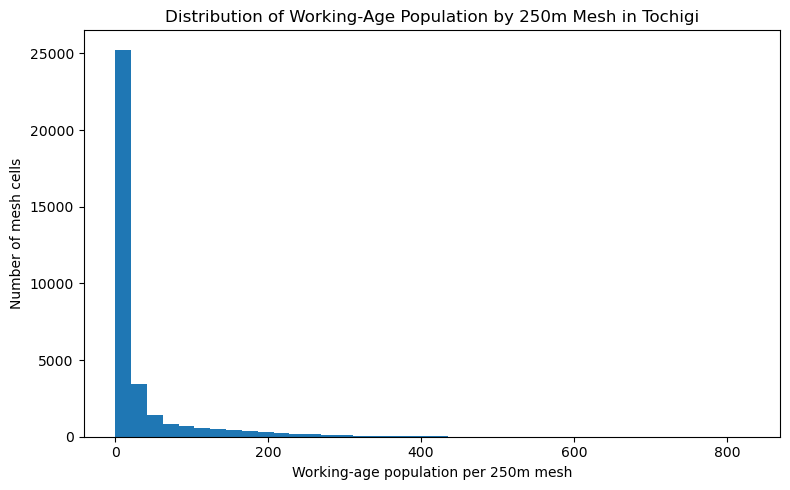

In [ ]:
# ============================================================
# Distribution of working-age population by 250m mesh
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

pop_mesh_tochigi[WORKING_POP_COL].plot(
    kind="hist",
    bins=40,
    ax=ax
)

ax.set_title("Distribution of Working-Age Population by 250m Mesh in Tochigi")
ax.set_xlabel("Working-age population per 250m mesh")
ax.set_ylabel("Number of mesh cells")

plt.tight_layout()
plt.show()

# 9. Analysis
### General Outline

The goal of the analysis was to estimate how much the Utsunomiya LRT improved public transportation accessibility to the Kiyohara industrial area. We compared two scenarios: Before-LRT and After-LRT. In both scenarios, the destination was the LRT stop at Kiyohara District Civic Center. The analysis used 30-minute and 60-minute travel-time thresholds.

The workflow followed five main steps:

1. Prepare spatial datasets and reproject them to EPSG:6678.
2. Build a multimodal transportation network using roads, bus routes, railway routes, and LRT stops.
3. Calculate 30-minute and 60-minute network-based accessibility polygons.
4. Compare Before-LRT and After-LRT accessibility areas.
5. Overlay the accessibility polygons with 250-meter population mesh data to estimate covered population and working-age population.

A simplified workflow diagram is:

text Spatial data   ↓ Road, bus, rail, and LRT network construction   ↓ NetworkX shortest-path analysis   ↓ 30-minute and 60-minute isochrone polygons   ↓ Overlay with 250 m population mesh   ↓ Covered area and covered population estimates

### Step 1: Build the walking network

The first step was to build a road-based walking network. Road features were clipped to a 50 km buffer around the destination to avoid cutting off potential routes at municipal boundaries. Road geometries were converted into line segments, and additional vertices were added at regular intervals. These vertices became NetworkX nodes, and each road segment became an edge. The travel-time weight of each edge was calculated as distance divided by walking speed. We assumed a walking speed of 80 meters per minute, or 4.8 km/h.

This road network was important because it represented walking from the origin, walking access to bus stops and railway stations, and walking transfers between different public transportation modes.

### Step 2: Add bus routes and bus stops

Next, the N07 bus route data were added to the graph. Bus route lines were also converted into graph nodes and edges. Bus travel time was estimated from the route distance using an assumed speed of 300 meters per minute (18 km/h). Bus stops from the P11 dataset were connected to both the road and bus route networks.

Because the graph was built as a directed graph, boarding and alighting could be treated differently. When entering the bus network, we added an 8-minute expected waiting-time penalty. This value was based on observed weekday morning-peak bus headways toward the eastern industrial area. When alighting from a bus, no waiting penalty was added.

### Step 3: Build the Before-LRT model

The Before-LRT scenario was first modeled using only walking and bus travel. We then added conventional railways to create the main Before-LRT model. Railway routes and stations from the N05 dataset were used, but LRT-related railway features were excluded because the LRT did not exist in the Before-LRT scenario.

Railway stations were connected to both the road and railway networks. Entering the rail network included a 10-minute expected waiting-time penalty, while alighting did not. Rail travel time was estimated using an assumed speed of 700 meters per minute (42 km/h).

For each time threshold, we used Dijkstra’s shortest-path algorithm in NetworkX to calculate the minimum travel time from the destination to all reachable graph nodes. Reachable road edges and nodes were then buffered by 25 meters and merged into road-based isochrone polygons. This produced 30-minute and 60-minute Before-LRT accessibility areas.

### Step 4: Build the After-LRT model

The After-LRT model added the Utsunomiya LRT network to the existing walking, bus, and conventional rail network. One point was created for each LRT stop, and an ordered LRT route line was constructed by connecting the stops.

LRT travel time was estimated at 20 km/h, or about 333 meters per minute. We also added a 5-minute expected LRT waiting time when boarding the LRT. The Kiyohara District Civic Center stop was connected directly to the origin node to ensure the After-LRT scenario reflected direct LRT access from the destination stop.

Using the same Dijkstra-based method, we calculated 30-minute and 60-minute After-LRT isochrone polygons.

### Step 5: Estimate population coverage

Finally, the Before-LRT and After-LRT accessibility polygons were overlaid with the 250-meter population mesh dataset. We used the 2025 total population variable and the 2025 working-age population variable. Because some population mesh cells were only partially covered by the accessibility polygons, population was estimated using area-weighted allocation. For each intersected mesh cell, we calculated the share of the mesh area covered by the isochrone polygon and multiplied the population value by that share.

This produced estimates of accessible area, total population covered, and working-age population covered for 30-minute and 60-minute thresholds before and after the LRT opening.

### Difference from the Project Proposal

The final analysis became more focused than the original proposal. At the proposal stage, we considered a broader study that included land prices, station passenger data, road traffic data, and possibly machine learning methods. However, during implementation, we narrowed the project to a clearer and more feasible research question: how much the LRT improved public transportation accessibility and population coverage around the Kiyohara industrial area.

This change improved the project's analytical consistency. Instead of combining many datasets with different spatial and temporal meanings, the final workflow focused on a reproducible network-based accessibility model. The main limitation is that the model uses route geometries, assumed speeds, and average waiting times rather than complete timetable data. Therefore, the resulting accessibility areas should be interpreted as simplified but systematic estimates rather than exact schedule-based travel-time areas.

## Model Design and Assumptions

This model is a simplified multimodal network model. It combines the following transportation components:

1. **Walking on the road network**
2. **Bus movement along N07 bus route geometries**
3. **Rail movement along non-LRT railway route geometries**
4. **Transfers through the road network**

In the main model, bus stops and railway stations are connected to the pedestrian road network. Therefore, walking transfers between bus stops, and between bus stops and railway stations, are allowed as long as the total travel time remains within the 30-minute or 60-minute limit. We do not impose a separate fixed transfer-distance cap, such as “within 5 minutes,” in the main model.

This model does not use GTFS or timetable data. Therefore, it does not account for service frequency, waiting time, actual departure times, vehicle schedules, or direction-specific operations. Instead, travel time is estimated from route geometry and assumed average speeds.

### Current assumptions

- Walking speed: 80 meters per minute, equivalent to 4.8 km/h
- Bus speed: 300 meters per minute, equivalent to 18 km/h
- Rail speed: 700 meters per minute, equivalent to 42 km/h
- Bus waiting time: 0 minutes
- Transfer penalty: 0 minutes
- Time limits: 30 minutes and 60 minutes
- Network calculation area: 50 km buffer around the origin
- CRS for analysis: EPSG:6678

Because waiting time, service frequency, and direction are not modeled, the resulting accessibility areas should be interpreted as simplified geometry-based accessibility estimates rather than exact timetable-based travel-time areas.

## Before-LRT

### Scenario Structure

This notebook creates the following Before-LRT model:

#### Model A: Bus + Road Walking

This model includes walking on the road network and bus travel along N07 bus route geometries. It does not include rail travel.

#### Model B: Bus + Road Walking + Rail

This model adds non-LRT rail routes and non-LRT railway stations to Model A. Railway stations are connected to both the road network and the railway network. Walking transfers between bus stops and railway stations are possible through the road network, without a separate transfer-time cap.

### Waiting-time penalty assumptions

In this version, waiting-time penalties are introduced to approximate transfer waiting time.

The waiting-time penalty is based on the assumption:

expected waiting time = average headway / 2

For buses, we use eastbound morning-peak bus services from Kōteyama Jūjiro toward the eastern industrial-area direction, which is consistent with the policy goal of reducing commuting congestion to the eastern industrial areas. The observed weekday 7:00–9:00 departures are:

7:06, 7:22, 7:39, 7:49, 8:09, 8:29, 8:47

The average interval is approximately 16.8 minutes, so the expected waiting time is approximately 8.4 minutes. We round this to:

BUS_WAIT_TIME_MIN = 8

For rail, we use the JR Utsunomiya Line at Utsunomiya Station as the representative rail service. Based on the weekday morning peak schedule, we set:

RAIL_WAIT_TIME_MIN = 10

TRANSFER_PENALTY_MIN is kept at 0 because physical walking transfers are already represented through the road network. The wait-time penalties are applied when entering the bus or rail route network, not when alighting.

In [ ]:
# ------------------------------------------------------------
# Waiting-time penalty assumptions
# ------------------------------------------------------------
# Expected waiting time is approximated as average headway / 2.
#
# BUS_WAIT_TIME_MIN:
#   Derived from eastbound weekday morning-peak bus services
#   from Kōteyama Jūjiro toward the eastern industrial-area direction.
#   Departures between 7:00 and 9:00:
#   7:06, 7:22, 7:39, 7:49, 8:09, 8:29, 8:47
#   Average headway ≈ 16.8 min, so expected waiting time ≈ 8.4 min.
#   Rounded to 8 min.
#
# RAIL_WAIT_TIME_MIN:
#   Derived from the JR Utsunomiya Line at Utsunomiya Station
#   during the weekday morning peak.
#
# TRANSFER_PENALTY_MIN:
#   Kept at 0 because physical walking transfers are already modeled
#   through the road network.
BUS_WAIT_TIME_MIN = 8
RAIL_WAIT_TIME_MIN = 10
TRANSFER_PENALTY_MIN = 0

### Model A Construction

In [ ]:
# ============================================================
# Build base graph with road walking network
# ============================================================

## This cell creates the road-based walking network.

## The road shapefile is first exploded into individual LineStrings.
## Each road line is then densified so that long road segments are split into smaller graph segments.
## The resulting vertices become NetworkX nodes, and consecutive vertices are connected by walking edges.

## Each road edge is assigned a travel-time weight:
##  walking time = road segment distance / walking speed

## This road network is used for walking from the origin, walking to and from bus stops, walking to and from railway stations, and generating the final accessibility polygons.

## Note
## The graph is created as a directed graph (`nx.DiGraph`) so that boarding and alighting can be treated differently.
## Road walking edges are still added in both directions, but later boarding edges can include wait-time penalties, while alighting edges can remain zero-cost.

G = nx.DiGraph()

# Prepare road lines
road_lines = explode_lines(roads_net).copy()

# Densify road lines
road_lines["geometry"] = road_lines.geometry.apply(
    lambda geom: densify_linestring(geom, ROAD_DENSIFY_INTERVAL_M)
)

print("Road lines after explode/densify:", road_lines.shape)

# Add road walking network
G = add_lines_to_graph(
    G=G,
    lines_gdf=road_lines,
    node_prefix="road",
    edge_type="walk_road",
    speed_m_per_min=WALK_SPEED_M_PER_MIN
)

print("Graph after road network:")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

road_nodes_gdf = graph_nodes_to_gdf(G, node_type_filter="road")
print("road_nodes_gdf:", road_nodes_gdf.shape)

## The output reports the number of road lines, graph nodes, and graph edges created from the road network.

## A large number of road nodes and edges is expected because the road network is dense and covers a wide 50 km area.
## This large graph is computationally heavy, but it is necessary for road-based walking accessibility.

Road lines after explode/densify: (916535, 10)
Graph after road network:
nodes: 2816980
edges: 6036930
road_nodes_gdf: (2816980, 3)


In [ ]:
# ============================================================
# Add N07 bus route network
# ============================================================

## This cell adds the N07 bus route geometries to the NetworkX graph.

## The bus route lines are exploded and densified in the same way as the road network.
## Consecutive vertices along the bus route lines are connected by bus-route edges.

## Each bus-route edge is assigned a travel-time weight:
##  bus travel time = bus route segment distance / assumed bus speed

## This model does not use timetables, service frequency, or direction-specific bus operations.
## Bus movement is modeled as movement along the N07 bus route geometries.

bus_route_lines = explode_lines(bus_routes_net).copy()

bus_route_lines["geometry"] = bus_route_lines.geometry.apply(
    lambda geom: densify_linestring(geom, BUS_ROUTE_DENSIFY_INTERVAL_M)
)

print("Bus route lines after explode/densify:", bus_route_lines.shape)

G = add_lines_to_graph(
    G=G,
    lines_gdf=bus_route_lines,
    node_prefix="busroute",
    edge_type="bus_route",
    speed_m_per_min=BUS_SPEED_M_PER_MIN
)

print("Graph after adding bus routes:")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

bus_route_nodes_gdf = graph_nodes_to_gdf(G, node_type_filter="busroute")
print("bus_route_nodes_gdf:", bus_route_nodes_gdf.shape)

## The output shows the number of bus route lines, graph nodes, and graph edges after adding the bus route network.

## The `bus_route_nodes_gdf` contains the internal route nodes used to represent movement along bus routes.
## These are not bus stops; they are graph nodes created from bus route line geometries.

Bus route lines after explode/densify: (4135, 3)
Graph after adding bus routes:
nodes: 2837346
edges: 6078436
bus_route_nodes_gdf: (20366, 3)


In [ ]:
# ============================================================
# Connect bus stops to roads and bus routes
# ============================================================

## This cell connects each bus stop to both the road network and the bus route network.

## The bus stop-to-road connection represents walking access and is added in both directions.

## The bus stop-to-bus-route connection is modeled asymmetrically using a directed graph:

## - bus stop → bus route: boarding edge with `BUS_WAIT_TIME_MIN`
## - bus route → bus stop: alighting edge with zero waiting time

## This allows the model to add an 8-minute expected bus waiting penalty when entering the bus network, without incorrectly adding the same penalty when getting off the bus.

bus_stops_net = bus_stops_net.reset_index(drop=True).copy()

# If bus_stop_id was lost after clip, recreate it safely
if "bus_stop_id" not in bus_stops_net.columns:
    bus_stops_net["bus_stop_id"] = bus_stops_net.index.map(lambda x: f"bus_stop_{x:05d}")

# 1. Bus stop -> road node, walking access
G, bus_stop_to_road_joined, bus_stop_to_road_snapped = connect_points_to_nearest_nodes(
    G=G,
    points_gdf=bus_stops_net,
    target_nodes_gdf=road_nodes_gdf,
    point_id_col="bus_stop_id",
    point_node_type="bus_stop",
    edge_type="bus_stop_to_road",
    speed_m_per_min=WALK_SPEED_M_PER_MIN,
    snap_tolerance_m=BUS_STOP_TO_ROAD_SNAP_TOLERANCE_M,
    connection_weight_override=None
)

print("Bus stops snapped to roads:", len(bus_stop_to_road_snapped))
print("Bus stops not snapped to roads:", len(bus_stop_to_road_joined) - len(bus_stop_to_road_snapped))

# 2. Bus stop -> bus route node, zero-cost geometry correction
G, bus_stop_to_route_joined, bus_stop_to_route_snapped = connect_points_to_route_nodes_asymmetric(
    G=G,
    points_gdf=bus_stop_to_road_snapped,
    target_nodes_gdf=bus_route_nodes_gdf,
    point_id_col="bus_stop_id",
    point_node_type="bus_stop",
    board_edge_type="bus_boarding",
    alight_edge_type="bus_alighting",
    snap_tolerance_m=BUS_STOP_TO_BUS_ROUTE_SNAP_TOLERANCE_M,
    boarding_wait_time_min=BUS_WAIT_TIME_MIN,
    transfer_penalty_min=TRANSFER_PENALTY_MIN
)

print("Bus stops snapped to bus routes:", len(bus_stop_to_route_snapped))
print("Bus stops not snapped to bus routes:", len(bus_stop_to_route_joined) - len(bus_stop_to_route_snapped))

print("Graph after connecting bus stops:")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

# Keep final usable bus stops
usable_bus_stops = bus_stop_to_route_snapped.copy()


## The output reports how many bus stops were successfully connected to the road network and the bus route network.

## Because the graph is directed, bus boarding and alighting are treated differently.
## Boarding a bus adds the expected waiting-time penalty, while alighting from a bus does not.
## This better represents transfer waiting time than the previous undirected zero-cost connector model.

Bus stops snapped to roads: 3375
Bus stops not snapped to roads: 0
Bus stops snapped to bus routes: 3375
Bus stops not snapped to bus routes: 0
Graph after connecting bus stops:
nodes: 2840721
edges: 6091936


In [ ]:
# ============================================================
# Connect origin to road network
# ============================================================

## This cell connects the origin point, `清原地区市民センター前`, to the nearest road network node.

## This connection allows the traveler to begin the trip by walking along the road network from the origin.
## The travel-time weight is based on the distance from the origin to the nearest road node divided by walking speed.

origin_for_graph = origin.rename(columns={"origin_id": "node_id"}).copy()
origin_for_graph["origin_graph_id"] = "origin_kiyohara"

origin_points = gpd.GeoDataFrame(
    {
        "origin_graph_id": ["origin_kiyohara"],
        "origin_name": [TARGET_LRT_STOP_NAME]
    },
    geometry=origin.geometry,
    crs=CRS_ANALYSIS
)

G, origin_to_road_joined, origin_to_road_snapped = connect_points_to_nearest_nodes(
    G=G,
    points_gdf=origin_points,
    target_nodes_gdf=road_nodes_gdf,
    point_id_col="origin_graph_id",
    point_node_type="origin",
    edge_type="origin_to_road",
    speed_m_per_min=WALK_SPEED_M_PER_MIN,
    snap_tolerance_m=ORIGIN_TO_ROAD_SNAP_TOLERANCE_M,
    connection_weight_override=None
)

if len(origin_to_road_snapped) == 0:
    raise ValueError("Origin could not be connected to the road network.")

ORIGIN_NODE_ID = "origin_kiyohara"

display(origin_to_road_joined)

print("Graph after connecting origin:")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

## The output shows the nearest road node to the origin and the snapping distance.

## A short snapping distance indicates that the origin is well connected to the road network.
## This is necessary because all trips begin from the origin through the road network.

,origin_graph_id,origin_name,geometry,index_right,target_node_id,snap_dist_m,is_snapped
0,origin_kiyohara,清原地区市民センター前,POINT (-76028.66 -382850.99),2429546,road_-75999.3_-382834.7,33.585305,True


Graph after connecting origin:
nodes: 2840722
edges: 6091938


In [ ]:
# ============================================================
# Isochrone function for bus + road walking model
# ============================================================

## This cell defines the functions used to compute 30-minute and 60-minute accessibility areas.

## The main steps are:
## 1. Use Dijkstra's shortest-path algorithm to calculate the minimum travel time from the origin to all reachable graph nodes.
## 2. Extract reachable road nodes and road edges.
## 3. Convert the reachable road network into an isochrone polygon by applying a small corridor buffer.
## 4. Return the reachable nodes, reachable road features, and the final polygon.

## The polygon is generated from reachable road-network features rather than from circular buffers.
## This makes the output consistent with a road-based walking accessibility model.

def compute_reachable_nodes(G, origin_node_id, time_limit_min):
    """
    Compute shortest travel times from origin to all reachable nodes.
    """
    travel_times = nx.single_source_dijkstra_path_length(
        G,
        source=origin_node_id,
        cutoff=time_limit_min,
        weight="weight"
    )

    return pd.DataFrame(
        list(travel_times.items()),
        columns=["node_id", "total_time_min"]
    )


def create_road_based_isochrone_polygon(G, reachable_df, buffer_m=ISOCHRONE_CORRIDOR_BUFFER_M):
    """
    Create a polygon from reachable road edges and road nodes.
    """
    reachable_set = set(reachable_df["node_id"])

    edge_geoms = []
    node_geoms = []

    # Reachable road edges
    for u, v, attrs in G.edges(data=True):
        if attrs.get("edge_type") != "walk_road":
            continue

        if u in reachable_set and v in reachable_set:
            geom = attrs.get("geometry")
            if geom is not None:
                edge_geoms.append(geom)

    # Reachable road nodes
    for node_id, attrs in G.nodes(data=True):
        if node_id not in reachable_set:
            continue

        if attrs.get("node_type") == "road":
            geom = attrs.get("geometry")
            if geom is not None:
                node_geoms.append(geom)

    edge_gdf = gpd.GeoDataFrame(
        {"type": ["edge"] * len(edge_geoms)},
        geometry=edge_geoms,
        crs=CRS_ANALYSIS
    )

    node_gdf = gpd.GeoDataFrame(
        {"type": ["node"] * len(node_geoms)},
        geometry=node_geoms,
        crs=CRS_ANALYSIS
    )

    buffered_geoms = []

    if len(edge_gdf) > 0:
        buffered_geoms.extend(edge_gdf.geometry.buffer(buffer_m).tolist())

    if len(node_gdf) > 0:
        buffered_geoms.extend(node_gdf.geometry.buffer(buffer_m).tolist())

    if len(buffered_geoms) == 0:
        return None, edge_gdf, node_gdf

    polygon = gpd.GeoSeries(buffered_geoms, crs=CRS_ANALYSIS).union_all()

    return polygon, edge_gdf, node_gdf


def compute_isochrone_for_time_limit(G, origin_node_id, time_limit_min, scenario_name):
    """
    Compute reachable nodes and a road-based polygon for a given time limit.
    """
    reachable_df = compute_reachable_nodes(
        G,
        origin_node_id=origin_node_id,
        time_limit_min=time_limit_min
    )

    polygon_geom, reachable_road_edges, reachable_road_nodes = create_road_based_isochrone_polygon(
        G,
        reachable_df,
        buffer_m=ISOCHRONE_CORRIDOR_BUFFER_M
    )

    if polygon_geom is None:
        raise ValueError(f"No polygon created for {time_limit_min} minutes.")

    polygon_gdf = gpd.GeoDataFrame(
        {
            "scenario": [scenario_name],
            "time_min": [time_limit_min],
            "origin": [TARGET_LRT_STOP_NAME],
            "walk_speed": [WALK_SPEED_M_PER_MIN],
            "bus_speed": [BUS_SPEED_M_PER_MIN],
            "wait_time": [BUS_WAIT_TIME_MIN],
            "transfer_penalty": [TRANSFER_PENALTY_MIN],
            "model": ["bus_plus_road_walking_no_rail"]
        },
        geometry=[polygon_geom],
        crs=CRS_ANALYSIS
    )

    return reachable_df, polygon_gdf, reachable_road_edges, reachable_road_nodes

In [ ]:
# ============================================================
# Compute 30-minute and 60-minute bus + road walking isochrones
# ============================================================

## This cell computes the 30-minute and 60-minute accessibility areas for Model A:
##  Model A = Bus + Road Walking, No Rail

## The model includes walking on the road network and bus travel along the N07 bus route network.
## It does not include railway travel.

## The output is saved as a GeoPackage for later comparison with the rail models and the post-LRT results.

isochrone_results = {}

for t in TIME_LIMITS:
    print(f"Computing {t}-minute isochrone...")

    reachable_df, polygon_gdf, road_edges_gdf, road_nodes_gdf = compute_isochrone_for_time_limit(
        G,
        origin_node_id=ORIGIN_NODE_ID,
        time_limit_min=t,
        scenario_name="pre_lrt_bus_road_walk"
    )

    isochrone_results[t] = {
        "reachable_df": reachable_df,
        "polygon": polygon_gdf,
        "road_edges": road_edges_gdf,
        "road_nodes": road_nodes_gdf
    }

    print(f"{t} min reachable nodes:", len(reachable_df))
    print(f"{t} min reachable road edges:", len(road_edges_gdf))
    print(f"{t} min reachable road nodes:", len(road_nodes_gdf))

# Combine polygons
pre_lrt_isochrones = pd.concat(
    [isochrone_results[t]["polygon"] for t in TIME_LIMITS],
    ignore_index=True
)

display(pre_lrt_isochrones)

# Save
pre_lrt_isochrones.to_file(
    GPKG_DIR / "pre_lrt_bus_road_walk_30_60min.gpkg",
    layer="isochrones",
    driver="GPKG"
)

## The output reports the number of reachable graph nodes, reachable road edges, and reachable road nodes for the 30-minute and 60-minute thresholds.

## The 60-minute values should be larger than the 30-minute values.
## The resulting polygons represent the Before-LRT bus-and-walking accessibility area without rail.

Computing 30-minute isochrone...
30 min reachable nodes: 7501
30 min reachable road edges: 15749
30 min reachable road nodes: 7037
Computing 60-minute isochrone...
60 min reachable nodes: 76522
60 min reachable road edges: 163912
60 min reachable road nodes: 73132


,scenario,time_min,origin,walk_speed,bus_speed,wait_time,transfer_penalty,model,geometry
0,pre_lrt_bus_road_walk,30,清原地区市民センター前,80,300,8,0,bus_plus_road_walking_no_rail,"MULTIPOLYGON (((-78778.844 -383662.127, -78779..."
1,pre_lrt_bus_road_walk,60,清原地区市民センター前,80,300,8,0,bus_plus_road_walking_no_rail,"MULTIPOLYGON (((-86859.996 -384798.228, -86860..."


In [ ]:
# ============================================================
# Extract reachable bus stops for diagnostics
# ============================================================

## This cell extracts bus stop nodes that are reachable within 30 minutes and 60 minutes under Model A.

## This is a diagnostic step. It helps us understand how many bus stops are reachable under the bus-and-road-walking model and whether the network is behaving as expected.

reachable_bus_stop_outputs = []

for t in TIME_LIMITS:
    reachable_df = isochrone_results[t]["reachable_df"]

    reachable_bus_ids = set(
        reachable_df[
            reachable_df["node_id"].astype(str).str.startswith("bus_stop_")
        ]["node_id"]
    )

    reachable_bus_stops_t = usable_bus_stops[
        usable_bus_stops["bus_stop_id"].isin(reachable_bus_ids)
    ].copy()

    reachable_bus_stops_t = reachable_bus_stops_t.merge(
        reachable_df.rename(columns={"node_id": "bus_stop_id"}),
        on="bus_stop_id",
        how="left"
    )

    reachable_bus_stops_t["time_limit"] = t

    print(f"{t} min reachable bus stops:", len(reachable_bus_stops_t))

    reachable_bus_stop_outputs.append(reachable_bus_stops_t)

reachable_bus_stops_all = pd.concat(reachable_bus_stop_outputs, ignore_index=True)

display(
    reachable_bus_stops_all[
        ["time_limit", "bus_stop_id", BUS_STOP_NAME_COL, BUS_OPERATOR_COL, "total_time_min", "geometry"]
    ].head(20)
)

reachable_bus_stops_all.to_file(
    GPKG_DIR / "pre_lrt_reachable_bus_stops_30_60min.gpkg",
    layer="reachable_bus_stops",
    driver="GPKG"
)

## The output reports the number of reachable bus stops for each time threshold.

## These counts are not the final accessibility measure, but they help validate the network model.
## A larger number of reachable bus stops in the 60-minute model indicates that the bus network is expanding the accessibility area beyond the immediate walking catchment.

30 min reachable bus stops: 67
60 min reachable bus stops: 552


,time_limit,bus_stop_id,P11_001,P11_002,total_time_min,geometry
0,30,bus_stop_02187,岡（十字路）,関東自動車（株）,28.719698,POINT (-79881.249 -383176.356)
1,30,bus_stop_02188,岡,ジェイアールバス関東（株）,28.719698,POINT (-79881.249 -383176.356)
2,30,bus_stop_02164,金田橋,関東自動車（株）,29.189973,POINT (-79705.274 -382969.431)
3,30,bus_stop_02450,小泉,関東自動車（株）,29.768178,POINT (-77633.871 -386451.663)
4,30,bus_stop_02423,一本杉,関東自動車（株）,28.541464,POINT (-77680.103 -386086.566)
5,30,bus_stop_02390,清原南小,関東自動車（株）,26.821593,POINT (-77707.395 -385571.35)
6,30,bus_stop_02373,海星学院,関東自動車（株）,24.960767,POINT (-76708.411 -385203.993)
7,30,bus_stop_02371,高田沼公園入口,関東自動車（株）,25.395304,POINT (-77727.61 -385143.947)
8,30,bus_stop_02339,氷室,関東自動車（株）,29.336186,POINT (-74921.212 -384700.225)
9,30,bus_stop_02331,松原（宇都宮）,関東自動車（株）,22.654983,POINT (-76883.882 -384551.443)


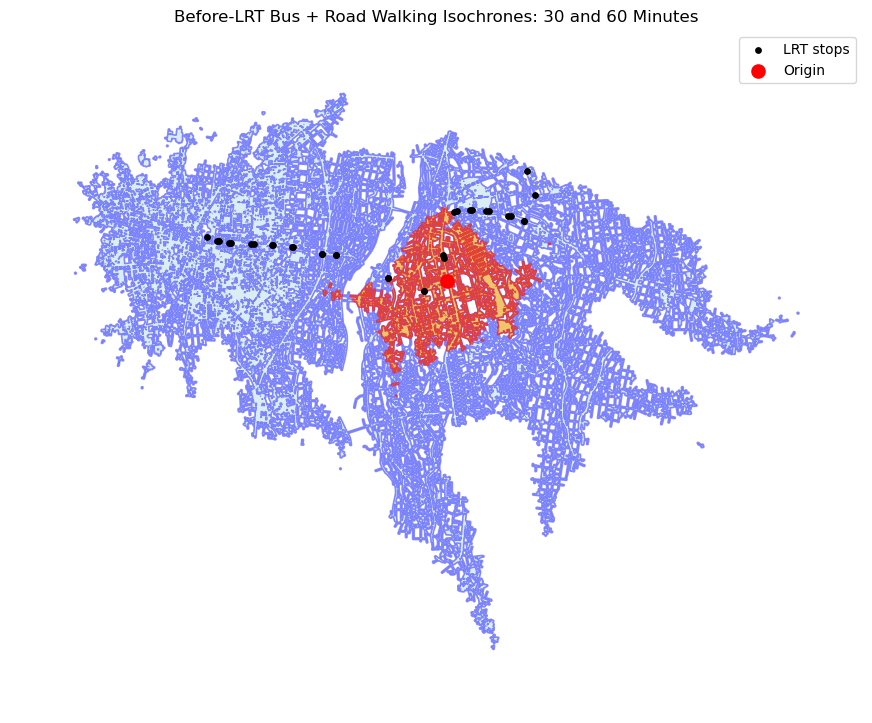

In [ ]:
# ============================================================
# Plot 30-minute and 60-minute polygons with zoom
# ============================================================

## This cell maps the 30-minute and 60-minute polygons for Model A.

## The 60-minute polygon is plotted first, and the 30-minute polygon is plotted on top.
## The origin and LRT stops are displayed for reference.

## This map is used to visually inspect the Before-LRT bus-and-walking accessibility area before adding rail.

poly_30 = pre_lrt_isochrones[pre_lrt_isochrones["time_min"] == 30]
poly_60 = pre_lrt_isochrones[pre_lrt_isochrones["time_min"] == 60]

fig, ax = plt.subplots(figsize=(11, 11))

# 60-min first, then 30-min on top
poly_60.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    alpha=0.45,
    linewidth=1.2,
    label="60 min"
)

poly_30.plot(
    ax=ax,
    color="orange",
    edgecolor="red",
    alpha=0.55,
    linewidth=1.2,
    label="30 min"
)

# LRT stops for reference
lrt_stops_net.plot(
    ax=ax,
    color="black",
    markersize=15,
    label="LRT stops"
)

# Origin
origin.plot(
    ax=ax,
    color="red",
    markersize=90,
    label="Origin"
)

# Zoom to 60-minute polygon bounds
minx, miny, maxx, maxy = poly_60.total_bounds
pad = 2000

ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_title("Before-LRT Bus + Road Walking Isochrones: 30 and 60 Minutes")
ax.set_axis_off()
ax.legend()

plt.show()

fig.savefig(
    FIG_DIR / "pre_lrt_bus_road_walk_30_60min_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

## The map shows the Before-LRT accessibility area under the bus-and-road-walking model.

## The 30-minute polygon represents the short-duration accessibility area near the origin.
## The 60-minute polygon represents the broader Before-LRT accessibility area reachable by a combination of walking and bus travel.

## If the polygon appears artificially cut off, this may indicate missing road data or disconnected road network features.
## In the current version, adding four road tiles has resolved the previous artificial truncation problem.

In [ ]:
# ============================================================
# Check whether non-LRT rail stations are inside 30/60-min polygons
# ============================================================

## This cell checks whether any non-LRT railway stations fall inside the 30-minute or 60-minute accessibility polygons from Model A.

## The LRT line is excluded because this is the Before-LRT scenario.
## Only pre-existing railway stations are considered.

## This step helps determine whether it is necessary to add rail travel to the model.

rail_stops_net = rail_stops_net.reset_index(drop=True).copy()

# Exclude LRT line from Before-LRT rail analysis
non_lrt_rail_stops = rail_stops_net[
    ~rail_stops_net[RAIL_LINE_COL].astype(str).str.contains(
        "宇都宮芳賀ライトレール|ライトレール|LRT",
        regex=True,
        na=False
    )
    &
    ~rail_stops_net[RAIL_OPERATOR_COL].astype(str).str.contains(
        "宇都宮ライトレール|ライトレール|LRT",
        regex=True,
        na=False
    )
].copy()

print("All rail/LRT stations in network area:", len(rail_stops_net))
print("Non-LRT rail stations:", len(non_lrt_rail_stops))

for t in TIME_LIMITS:
    poly = pre_lrt_isochrones[pre_lrt_isochrones["time_min"] == t].geometry.iloc[0]

    non_lrt_rail_stops[f"inside_{t}min"] = non_lrt_rail_stops.geometry.within(poly)

    print(f"\nNon-LRT rail stations inside {t}-min polygon:", non_lrt_rail_stops[f"inside_{t}min"].sum())

    display(
        non_lrt_rail_stops[
            non_lrt_rail_stops[f"inside_{t}min"]
        ][[RAIL_LINE_COL, RAIL_OPERATOR_COL, RAIL_STATION_NAME_COL, "geometry"]]
    )

## The output shows that no non-LRT railway stations are inside the 30-minute polygon, while several non-LRT railway stations are inside the 60-minute polygon.

## This suggests that rail is not relevant for short-duration accessibility from the origin, but rail may affect the 60-minute accessibility area.
## Therefore, a rail-augmented Before-LRT model is worth testing.

All rail/LRT stations in network area: 391
Non-LRT rail stations: 372

Non-LRT rail stations inside 30-min polygon: 0


,N05_002,N05_003,N05_011,geometry



Non-LRT rail stations inside 60-min polygon: 1


,N05_002,N05_003,N05_011,geometry
176,宇都宮線,東武鉄道,花房町,POINT (-85177.554 -382566.977)


### Model A Diagnostic

In [ ]:
# ============================================================
# How many rail stations are near the 60-min polygon?
# ============================================================

# Get 60-min polygon
poly_60_geom = pre_lrt_isochrones[
    pre_lrt_isochrones["time_min"] == 60
].geometry.iloc[0]

print("Non-LRT rail stations near 60-min polygon")

for dist in [0, 100, 250, 500, 1000]:

    count = non_lrt_rail_stops.geometry.within(
        poly_60_geom.buffer(dist)
    ).sum()

    print(f"Buffer {dist:4d} m : {count:3d} stations")


Non-LRT rail stations near 60-min polygon
Buffer    0 m :   1 stations
Buffer  100 m :   8 stations
Buffer  250 m :  10 stations
Buffer  500 m :  12 stations
Buffer 1000 m :  15 stations


In [ ]:
# ============================================================
# Check bus stop to road snap distance distribution
# ============================================================

snap_dist = bus_stop_to_road_joined["snap_dist_m"].dropna()

print("Bus stop to road snap distance summary:")
display(snap_dist.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

thresholds = [100, 200, 300, 500, 800, 1000, 1500, 2000]

for th in thresholds:
    n = (snap_dist <= th).sum()
    print(f"Within {th:4d} m: {n:5d} / {len(snap_dist)} ({n / len(snap_dist):.1%})")

Bus stop to road snap distance summary:


count    3375.000000
mean       10.549304
std        15.163554
min         0.087418
50%         3.520934
75%        11.723724
90%        35.294584
95%        47.222648
99%        65.565758
max        77.150690
Name: snap_dist_m, dtype: float64

Within  100 m:  3375 / 3375 (100.0%)
Within  200 m:  3375 / 3375 (100.0%)
Within  300 m:  3375 / 3375 (100.0%)
Within  500 m:  3375 / 3375 (100.0%)
Within  800 m:  3375 / 3375 (100.0%)
Within 1000 m:  3375 / 3375 (100.0%)
Within 1500 m:  3375 / 3375 (100.0%)
Within 2000 m:  3375 / 3375 (100.0%)


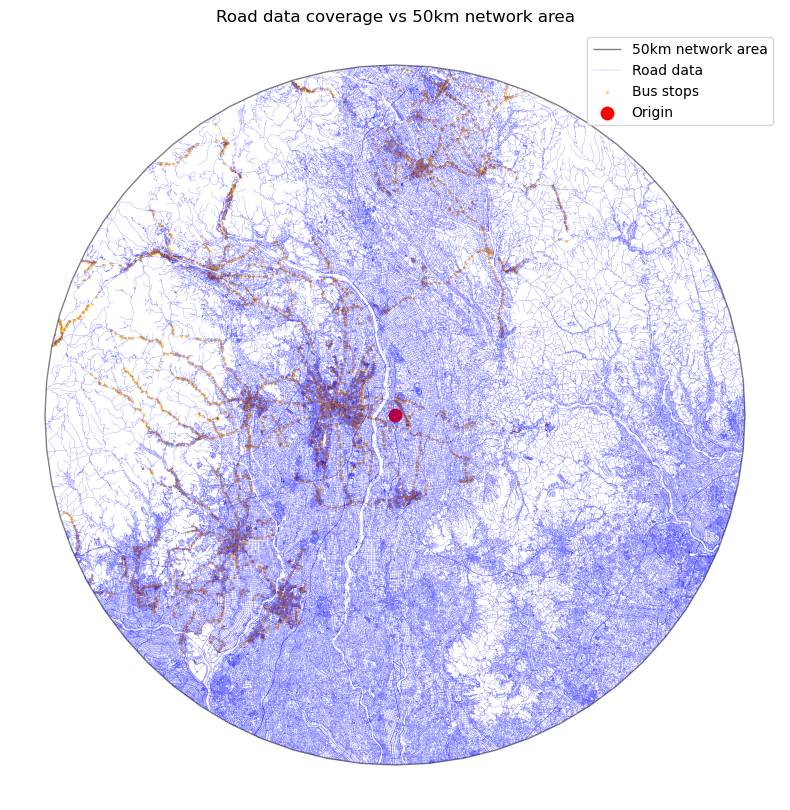

In [ ]:
# ============================================================
# Check road data coverage
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

network_area.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1,
    label="50km network area"
)

roads_net.plot(
    ax=ax,
    color="blue",
    linewidth=0.2,
    alpha=0.5,
    label="Road data"
)

bus_stops_net.plot(
    ax=ax,
    color="orange",
    markersize=2,
    alpha=0.4,
    label="Bus stops"
)

origin.plot(
    ax=ax,
    color="red",
    markersize=80,
    label="Origin"
)

ax.set_title("Road data coverage vs 50km network area")
ax.set_axis_off()
ax.legend()

plt.show()

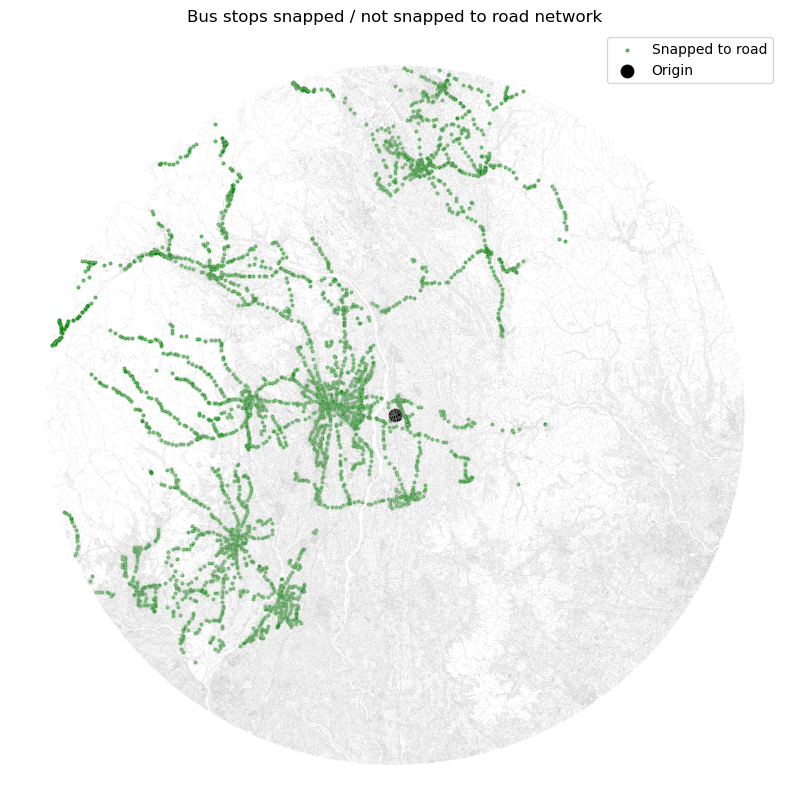

In [ ]:
# ============================================================
# Map bus stops not snapped to road network
# ============================================================

unsnapped_to_road = bus_stop_to_road_joined[
    ~bus_stop_to_road_joined["is_snapped"]
].copy()

snapped_to_road = bus_stop_to_road_joined[
    bus_stop_to_road_joined["is_snapped"]
].copy()

fig, ax = plt.subplots(figsize=(10, 10))

roads_net.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2,
    alpha=0.6
)

snapped_to_road.plot(
    ax=ax,
    color="green",
    markersize=4,
    alpha=0.5,
    label="Snapped to road"
)

unsnapped_to_road.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.7,
    label="Not snapped to road"
)

origin.plot(
    ax=ax,
    color="black",
    markersize=80,
    label="Origin"
)

ax.set_title("Bus stops snapped / not snapped to road network")
ax.set_axis_off()
ax.legend()

plt.show()

### Model B Construction

In [ ]:
# ============================================================
# Rail model parameters
# ============================================================

## This cell defines parameters for adding rail travel to the network.

## The rail speed is assumed rather than derived from a timetable.
## The rail densification interval controls how finely the railway line geometries are converted into graph edges.

## The bus-rail transfer distance parameter is used only for the optional direct-transfer sensitivity model.
## It is not part of the main rail model.

# Rail speed assumption
# 700 m/min = 42 km/h
# Adjust if the team wants a more conservative or faster rail speed.
RAIL_SPEED_M_PER_MIN = 700

# Densify interval for rail lines
RAIL_DENSIFY_INTERVAL_M = 200

# Snapping tolerances
RAIL_STATION_TO_ROAD_SNAP_TOLERANCE_M = 300
RAIL_STATION_TO_RAIL_ROUTE_SNAP_TOLERANCE_M = 300

# Bus stop to rail station direct transfer assumption
BUS_RAIL_TRANSFER_WALK_MIN = 5
BUS_RAIL_TRANSFER_DISTANCE_M = BUS_RAIL_TRANSFER_WALK_MIN * WALK_SPEED_M_PER_MIN

print("RAIL_SPEED_M_PER_MIN:", RAIL_SPEED_M_PER_MIN)
print("RAIL_DENSIFY_INTERVAL_M:", RAIL_DENSIFY_INTERVAL_M)
print("BUS_RAIL_TRANSFER_DISTANCE_M:", BUS_RAIL_TRANSFER_DISTANCE_M)

RAIL_SPEED_M_PER_MIN: 700
RAIL_DENSIFY_INTERVAL_M: 200
BUS_RAIL_TRANSFER_DISTANCE_M: 400


In [ ]:
# ============================================================
# Prepare non-LRT rail data for Before-LRT scenario
# ============================================================

## This cell removes LRT stations and LRT route sections from the railway dataset.

## Because this notebook estimates the Before-LRT scenario, the Utsunomiya LRT line should not be included as an available transportation mode.

## The resulting non-LRT railway station and route layers are used to build the rail component of the Before-LRT network.

# Ensure rail station ID exists after clipping
rail_stops_net = rail_stops_net.reset_index(drop=True).copy()

if "rail_station_id" not in rail_stops_net.columns:
    rail_stops_net["rail_station_id"] = rail_stops_net.index.map(lambda x: f"rail_station_{x:05d}")

# Exclude LRT stops from rail station data
non_lrt_rail_stops = rail_stops_net[
    ~rail_stops_net[RAIL_LINE_COL].astype(str).str.contains(
        "宇都宮芳賀ライトレール|ライトレール|LRT",
        regex=True,
        na=False
    )
    &
    ~rail_stops_net[RAIL_OPERATOR_COL].astype(str).str.contains(
        "宇都宮ライトレール|ライトレール|LRT",
        regex=True,
        na=False
    )
].copy()

# Exclude LRT route sections from rail route data
non_lrt_rail_routes = rail_routes_net[
    ~rail_routes_net[RAIL_LINE_COL].astype(str).str.contains(
        "宇都宮芳賀ライトレール|ライトレール|LRT",
        regex=True,
        na=False
    )
    &
    ~rail_routes_net[RAIL_OPERATOR_COL].astype(str).str.contains(
        "宇都宮ライトレール|ライトレール|LRT",
        regex=True,
        na=False
    )
].copy()

print("All rail/LRT stations:", len(rail_stops_net))
print("Non-LRT rail stations:", len(non_lrt_rail_stops))

print("All rail/LRT routes:", len(rail_routes_net))
print("Non-LRT rail routes:", len(non_lrt_rail_routes))

display(non_lrt_rail_stops[[RAIL_LINE_COL, RAIL_OPERATOR_COL, RAIL_STATION_NAME_COL, "rail_station_id", "geometry"]].head())
display(non_lrt_rail_routes[[RAIL_LINE_COL, RAIL_OPERATOR_COL, "geometry"]].head())

## The output reports the number of rail and LRT features before and after excluding the LRT.

## The non-LRT railway dataset should include conventional railway lines and stations, while excluding the Utsunomiya LRT line.

All rail/LRT stations: 391
Non-LRT rail stations: 372
All rail/LRT routes: 57
Non-LRT rail routes: 56


,N05_002,N05_003,N05_011,rail_station_id,geometry
0,日光線,東武鉄道,柳生,rail_station_05019,POINT (-105511.192 -420382.596)
1,日光線,東武鉄道,板倉東洋大前,rail_station_05018,POINT (-106508.87 -418637.583)
2,日光線,東武鉄道,藤岡,rail_station_05013,POINT (-106735.443 -414930.425)
3,両毛線,東日本旅客鉄道（旧国鉄）,岩舟,rail_station_04335,POINT (-105532.614 -407067.963)
4,両毛線,東日本旅客鉄道（旧国鉄）,小野寺,rail_station_04349,POINT (-107480.717 -407021.316)


,N05_002,N05_003,geometry
420,両毛線,東日本旅客鉄道（旧国鉄）,"LINESTRING (-92217.542 -408809.48, -92185.839 ..."
419,両毛線,東日本旅客鉄道（旧国鉄）,"LINESTRING (-92217.542 -408809.48, -92185.839 ..."
523,足尾線,東日本旅客鉄道（旧国鉄）,"LINESTRING (-125011.597 -372871.601, -124939.2..."
522,足尾線,東日本旅客鉄道（旧国鉄）,"LINESTRING (-125011.597 -372871.601, -124939.2..."
521,わたらせ渓谷線,わたらせ渓谷鐵道,"LINESTRING (-125011.597 -372871.601, -124939.2..."


In [ ]:
# ============================================================
# Add non-LRT rail route network to graph
# ============================================================

## This cell adds conventional railway routes to the NetworkX graph.

## The non-LRT railway route lines are exploded and densified.
## Consecutive vertices along the railway lines are connected by rail-route edges.

## Each rail edge is assigned a travel-time weight:
##  rail travel time = rail segment distance / assumed rail speed

## This creates the rail travel component of the Before-LRT multimodal network.

rail_route_lines = explode_lines(non_lrt_rail_routes).copy()

rail_route_lines["geometry"] = rail_route_lines.geometry.apply(
    lambda geom: densify_linestring(geom, RAIL_DENSIFY_INTERVAL_M)
)

print("Non-LRT rail route lines after explode/densify:", rail_route_lines.shape)

G = add_lines_to_graph(
    G=G,
    lines_gdf=rail_route_lines,
    node_prefix="rail",
    edge_type="rail_route",
    speed_m_per_min=RAIL_SPEED_M_PER_MIN
)

print("Graph after adding rail routes:")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

rail_route_nodes_gdf = graph_nodes_to_gdf(G, node_type_filter="rail")
print("rail_route_nodes_gdf:", rail_route_nodes_gdf.shape)

## The output shows how many railway route nodes and edges were added to the graph.

## These rail route nodes are internal graph nodes representing movement along railway lines.
## They are not railway stations.
## Railway station points are connected to this rail network in the next step.

Non-LRT rail route lines after explode/densify: (59, 12)
Graph after adding rail routes:
nodes: 2844859
edges: 6100164
rail_route_nodes_gdf: (4137, 3)


In [ ]:
print("road_nodes_gdf columns:")
print(road_nodes_gdf.columns.tolist())

print("rail_route_nodes_gdf columns:")
print(rail_route_nodes_gdf.columns.tolist())

display(road_nodes_gdf.head())
display(rail_route_nodes_gdf.head())

road_nodes_gdf columns:
['type', 'geometry']
rail_route_nodes_gdf columns:
['node_id', 'node_type', 'geometry']


,type,geometry
0,node,POINT (-74564.558 -394364.559)
1,node,POINT (-74561.859 -394348.436)
2,node,POINT (-74560.799 -394340.502)
3,node,POINT (-74559.213 -394321.815)
4,node,POINT (-74610.605 -394345.911)


,node_id,node_type,geometry
0,rail_-92217.5_-408809.5,rail,POINT (-92217.542 -408809.48)
1,rail_-92131.8_-408628.8,rail,POINT (-92131.807 -408628.79)
2,rail_-92061.0_-408442.2,rail,POINT (-92061.01 -408442.194)
3,rail_-91992.6_-408255.4,rail,POINT (-91992.609 -408255.374)
4,rail_-91904.5_-408075.8,rail,POINT (-91904.522 -408075.817)


In [ ]:
# ============================================================
# Recreate node GeoDataFrames from graph before rail station snapping
# ============================================================

## This cell recreates the road, bus route, and rail route node GeoDataFrames directly from the current NetworkX graph.

## This is included because repeated spatial joins can leave behind helper columns or outdated node GeoDataFrames.
## Recreating the node GeoDataFrames ensures that later snapping operations use the current graph structure and contain the required `node_id` and `geometry` columns.

road_nodes_gdf = graph_nodes_to_gdf(G, node_type_filter="road")
bus_route_nodes_gdf = graph_nodes_to_gdf(G, node_type_filter="busroute")
rail_route_nodes_gdf = graph_nodes_to_gdf(G, node_type_filter="rail")

print("road_nodes_gdf:", road_nodes_gdf.shape)
print("bus_route_nodes_gdf:", bus_route_nodes_gdf.shape)
print("rail_route_nodes_gdf:", rail_route_nodes_gdf.shape)

print("\nroad_nodes_gdf columns:")
print(road_nodes_gdf.columns.tolist())

print("\nrail_route_nodes_gdf columns:")
print(rail_route_nodes_gdf.columns.tolist())

# Basic validation
required_cols = {"node_id", "geometry"}

for name, gdf in {
    "road_nodes_gdf": road_nodes_gdf,
    "bus_route_nodes_gdf": bus_route_nodes_gdf,
    "rail_route_nodes_gdf": rail_route_nodes_gdf,
}.items():
    missing = required_cols - set(gdf.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

## The output confirms that the road, bus route, and rail route node GeoDataFrames have been recreated successfully from the current graph.

## Each GeoDataFrame should include at least:
## - `node_id`
## - `node_type`
## - `geometry`

## If these columns are present, the next snapping step can proceed safely.

road_nodes_gdf: (2816980, 3)
bus_route_nodes_gdf: (20366, 3)
rail_route_nodes_gdf: (4137, 3)

road_nodes_gdf columns:
['node_id', 'node_type', 'geometry']

rail_route_nodes_gdf columns:
['node_id', 'node_type', 'geometry']


In [ ]:
# ============================================================
# Connect non-LRT rail stations to roads and rail routes
# ============================================================

## This cell connects each non-LRT railway station to both the road network and the rail route network.

## The station-to-road connection represents walking access and is added in both directions.

## The station-to-rail-route connection is modeled asymmetrically:
## - railway station → rail route: boarding edge with `RAIL_WAIT_TIME_MIN`
## - rail route → railway station: alighting edge with zero waiting time

## This allows the model to add a 10-minute expected rail waiting penalty when entering the rail network, without adding a penalty when alighting.

# 1. Rail station -> road node, walking access
G, rail_station_to_road_joined, rail_station_to_road_snapped = connect_points_to_nearest_nodes(
    G=G,
    points_gdf=non_lrt_rail_stops,
    target_nodes_gdf=road_nodes_gdf,
    point_id_col="rail_station_id",
    point_node_type="rail_station",
    edge_type="rail_station_to_road",
    speed_m_per_min=WALK_SPEED_M_PER_MIN,
    snap_tolerance_m=RAIL_STATION_TO_ROAD_SNAP_TOLERANCE_M,
    connection_weight_override=None
)

print("Rail stations snapped to roads:", len(rail_station_to_road_snapped))
print("Rail stations not snapped to roads:", len(rail_station_to_road_joined) - len(rail_station_to_road_snapped))

# 2. Rail station -> rail route node, zero-cost geometry correction
G, rail_station_to_route_joined, rail_station_to_route_snapped = connect_points_to_route_nodes_asymmetric(
    G=G,
    points_gdf=rail_station_to_road_snapped,
    target_nodes_gdf=rail_route_nodes_gdf,
    point_id_col="rail_station_id",
    point_node_type="rail_station",
    board_edge_type="rail_boarding",
    alight_edge_type="rail_alighting",
    snap_tolerance_m=RAIL_STATION_TO_RAIL_ROUTE_SNAP_TOLERANCE_M,
    boarding_wait_time_min=RAIL_WAIT_TIME_MIN,
    transfer_penalty_min=TRANSFER_PENALTY_MIN
)

print("Rail stations snapped to rail routes:", len(rail_station_to_route_snapped))
print("Rail stations not snapped to rail routes:", len(rail_station_to_route_joined) - len(rail_station_to_route_snapped))

print("Graph after connecting rail stations:")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

usable_rail_stations = rail_station_to_route_snapped.copy()

display(
    usable_rail_stations[
        ["rail_station_id", RAIL_LINE_COL, RAIL_OPERATOR_COL, RAIL_STATION_NAME_COL, "geometry"]
    ].head()
)

## The output reports how many non-LRT railway stations were successfully connected to the road network and the railway route network.

## Because the graph is directed, entering the rail network now includes the expected rail waiting-time penalty, while exiting the rail network does not.

Rail stations snapped to roads: 372
Rail stations not snapped to roads: 0
Rail stations snapped to rail routes: 372
Rail stations not snapped to rail routes: 0
Graph after connecting rail stations:
nodes: 2845231
edges: 6101652


,rail_station_id,N05_002,N05_003,N05_011,geometry
0,rail_station_05019,日光線,東武鉄道,柳生,POINT (-105511.192 -420382.596)
1,rail_station_05018,日光線,東武鉄道,板倉東洋大前,POINT (-106508.87 -418637.583)
2,rail_station_05013,日光線,東武鉄道,藤岡,POINT (-106735.443 -414930.425)
3,rail_station_04335,両毛線,東日本旅客鉄道（旧国鉄）,岩舟,POINT (-105532.614 -407067.963)
4,rail_station_04349,両毛線,東日本旅客鉄道（旧国鉄）,小野寺,POINT (-107480.717 -407021.316)


In [ ]:
# ============================================================
# Compute 30/60-minute isochrones with rail and unrestricted walking transfers
# ============================================================

## This cell computes 30-minute and 60-minute isochrones for Model B:
##  Model B = Bus + Road Walking + Rail + Mode-specific waiting penalties

## The model includes:
## - road-network walking
## - bus travel with an 8-minute boarding wait penalty
## - rail travel with a 10-minute boarding wait penalty
## - zero additional transfer penalty
## - walking transfers through the road network

## Because the graph is directed, waiting time is added when boarding a bus or train, but not when alighting.

rail_isochrone_results = {}

for t in TIME_LIMITS:
    print(f"Computing {t}-minute isochrone with rail and unrestricted walking transfers...")

    reachable_df, polygon_gdf, road_edges_gdf, road_nodes_gdf = compute_isochrone_for_time_limit(
        G,
        origin_node_id=ORIGIN_NODE_ID,
        time_limit_min=t,
        scenario_name="pre_lrt_bus_road_walk_rail_unrestricted_transfers"
    )

    polygon_gdf["model"] = "bus_plus_road_walking_plus_rail_unrestricted_walk_transfers"

    rail_isochrone_results[t] = {
        "reachable_df": reachable_df,
        "polygon": polygon_gdf,
        "road_edges": road_edges_gdf,
        "road_nodes": road_nodes_gdf
    }

    print(f"{t} min reachable nodes:", len(reachable_df))
    print(f"{t} min reachable road edges:", len(road_edges_gdf))
    print(f"{t} min reachable road nodes:", len(road_nodes_gdf))

pre_lrt_isochrones_with_rail = pd.concat(
    [rail_isochrone_results[t]["polygon"] for t in TIME_LIMITS],
    ignore_index=True
)

display(pre_lrt_isochrones_with_rail)

pre_lrt_isochrones_with_rail.to_file(
    GPKG_DIR / "pre_lrt_bus_road_walk_rail_unrestricted_transfers_30_60min.gpkg",
    layer="isochrones",
    driver="GPKG"
)

## The output reports the reachable nodes, road edges, and road nodes after adding rail travel.

## If the 60-minute polygon increases relative to Model A, this suggests that access to pre-existing railways expands the Before-LRT accessibility area. If the 30-minute polygon does not change, it suggests that rail is not relevant for short-duration accessibility from this origin.

Computing 30-minute isochrone with rail and unrestricted walking transfers...
30 min reachable nodes: 7501
30 min reachable road edges: 15749
30 min reachable road nodes: 7037
Computing 60-minute isochrone with rail and unrestricted walking transfers...
60 min reachable nodes: 76571
60 min reachable road edges: 163912
60 min reachable road nodes: 73132


,scenario,time_min,origin,walk_speed,bus_speed,wait_time,transfer_penalty,model,geometry
0,pre_lrt_bus_road_walk_rail_unrestricted_transfers,30,清原地区市民センター前,80,300,8,0,bus_plus_road_walking_plus_rail_unrestricted_w...,"MULTIPOLYGON (((-78778.844 -383662.127, -78779..."
1,pre_lrt_bus_road_walk_rail_unrestricted_transfers,60,清原地区市民センター前,80,300,8,0,bus_plus_road_walking_plus_rail_unrestricted_w...,"MULTIPOLYGON (((-86859.996 -384798.228, -86860..."


Reachable rail stations within 60 min: 5


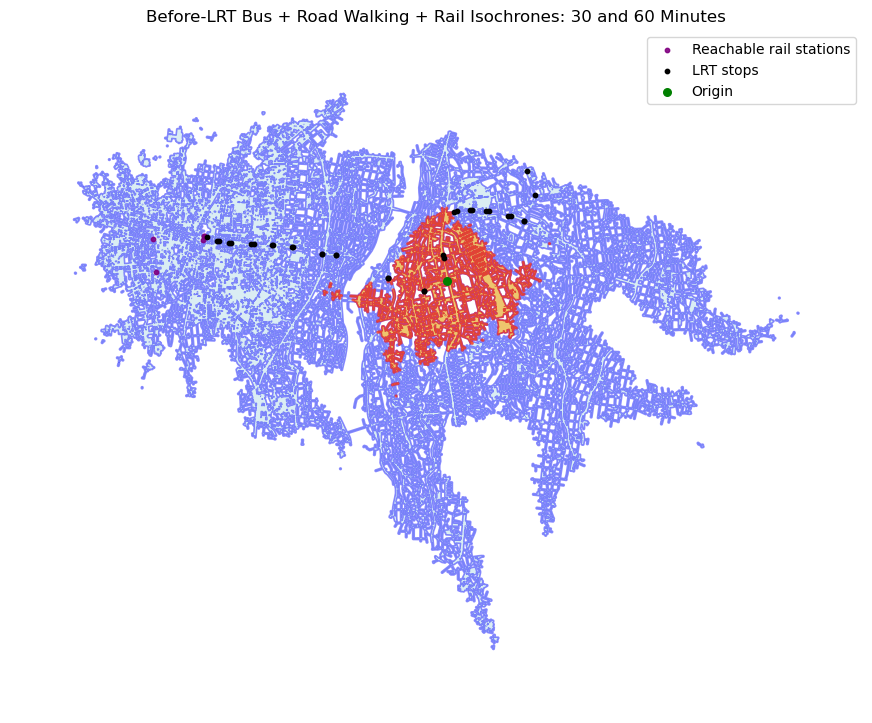

In [ ]:
# ============================================================
# Cell 21 revised: Plot 30/60-minute isochrones with reachable rail stations only
# ============================================================

## This cell maps the 30-minute and 60-minute polygons for Model B.

## Only reachable non-LRT railway stations are displayed.
## The station points are shown for reference and are not used to define the polygon directly.
## The polygon itself is generated from reachable road-network features.

poly_30_rail = pre_lrt_isochrones_with_rail[
    pre_lrt_isochrones_with_rail["time_min"] == 30
]

poly_60_rail = pre_lrt_isochrones_with_rail[
    pre_lrt_isochrones_with_rail["time_min"] == 60
]

# ------------------------------------------------------------
# Extract reachable rail stations within 60 minutes
# ------------------------------------------------------------

reachable_rail_60_ids = set(
    rail_isochrone_results[60]["reachable_df"][
        rail_isochrone_results[60]["reachable_df"]["node_id"].astype(str).str.startswith("rail_station_")
    ]["node_id"]
)

reachable_rail_60 = usable_rail_stations[
    usable_rail_stations["rail_station_id"].isin(reachable_rail_60_ids)
].copy()

print("Reachable rail stations within 60 min:", len(reachable_rail_60))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 11))

# 60-min first, then 30-min on top
poly_60_rail.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    alpha=0.45,
    linewidth=1.2,
    label="60 min"
)

poly_30_rail.plot(
    ax=ax,
    color="orange",
    edgecolor="red",
    alpha=0.55,
    linewidth=1.2,
    label="30 min"
)

# Reachable rail stations only; no color differentiation
reachable_rail_60.plot(
    ax=ax,
    color="purple",
    markersize=10,
    alpha=0.9,
    label="Reachable rail stations"
)

# LRT stops for reference only
lrt_stops_net.plot(
    ax=ax,
    color="black",
    markersize=10,
    label="LRT stops"
)

origin.plot(
    ax=ax,
    color="green",
    markersize=30,
    label="Origin"
)

# Zoom to 60-min polygon
minx, miny, maxx, maxy = poly_60_rail.total_bounds
pad = 2000
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_title("Before-LRT Bus + Road Walking + Rail Isochrones: 30 and 60 Minutes")
ax.set_axis_off()
ax.legend()

plt.show()

fig.savefig(
    FIG_DIR / "pre_lrt_bus_road_walk_rail_30_60min_reachable_rail_only.png",
    dpi=300,
    bbox_inches="tight"
)

## The map shows the Before-LRT accessibility area after adding conventional rail travel.

## Reachable railway stations are displayed to show which stations are actually accessible within the modeled travel-time budget.
## If the map looks similar to Model A, the effect of rail may be modest.
## This should be confirmed using the area summary table.

### Model B Diagnostic

In [ ]:
# ============================================================
# Diagnose reachable rail stations with rail model
# ============================================================

## This cell extracts the railway station nodes that are reachable within 30 minutes and 60 minutes under Model B.

## This step helps identify which railway stations are actually used or accessible in the multimodal Before-LRT network.

reachable_rail_station_outputs = []

for t in TIME_LIMITS:
    reachable_df = rail_isochrone_results[t]["reachable_df"]

    reachable_rail_ids = set(
        reachable_df[
            reachable_df["node_id"].astype(str).str.startswith("rail_station_")
        ]["node_id"]
    )

    reachable_rail_stations_t = usable_rail_stations[
        usable_rail_stations["rail_station_id"].isin(reachable_rail_ids)
    ].copy()

    reachable_rail_stations_t = reachable_rail_stations_t.merge(
        reachable_df.rename(columns={"node_id": "rail_station_id"}),
        on="rail_station_id",
        how="left"
    )

    reachable_rail_stations_t["time_limit"] = t

    print(f"{t} min reachable rail stations:", len(reachable_rail_stations_t))

    display(
        reachable_rail_stations_t[
            ["time_limit", "rail_station_id", RAIL_LINE_COL, RAIL_OPERATOR_COL, RAIL_STATION_NAME_COL, "total_time_min", "geometry"]
        ].sort_values("total_time_min").head(30)
    )

    reachable_rail_station_outputs.append(reachable_rail_stations_t)

reachable_rail_stations_all = pd.concat(
    reachable_rail_station_outputs,
    ignore_index=True
)

reachable_rail_stations_all.to_file(
    GPKG_DIR / "pre_lrt_reachable_rail_stations_30_60min.gpkg",
    layer="reachable_rail_stations",
    driver="GPKG"
)

## The output shows that no non-LRT railway stations are reachable within 30 minutes, while several railway stations are reachable within 60 minutes.

## This supports the interpretation that conventional rail affects the broader 60-minute accessibility area, but not the shorter 30-minute accessibility area.

30 min reachable rail stations: 0


,time_limit,rail_station_id,N05_002,N05_003,N05_011,total_time_min,geometry


60 min reachable rail stations: 5


,time_limit,rail_station_id,N05_002,N05_003,N05_011,total_time_min,geometry
1,60,rail_station_02032,東北新幹線,東日本旅客鉄道（旧国鉄）,宇都宮,45.885648,POINT (-83718.832 -381537.689)
3,60,rail_station_02125,東北線,東日本旅客鉄道（旧国鉄）,宇都宮,45.901130,POINT (-83659.771 -381429.843)
4,60,rail_station_04227,日光線,東日本旅客鉄道（旧国鉄）,宇都宮,45.901130,POINT (-83659.771 -381429.843)
2,60,rail_station_05033,宇都宮線,東武鉄道,東武宇都宮,52.805339,POINT (-85284.622 -381534.529)
0,60,rail_station_05039,宇都宮線,東武鉄道,花房町,54.475893,POINT (-85177.554 -382566.977)


In [ ]:
# ============================================================
# Diagnose walking connectivity between bus stops through road network
# ============================================================

## This diagnostic cell examines whether nearby bus stops exist within the reachable 60-minute area.

## The model already allows walking between bus stops through the road network because bus stops are connected to road nodes.
## This cell does not add new edges.
## It only identifies nearby bus-stop pairs within 400 meters straight-line distance as a diagnostic check.

# Use 60-min reachable result from rail model
reachable_df_60 = rail_isochrone_results[60]["reachable_df"].copy()
reachable_node_ids_60 = set(reachable_df_60["node_id"])

# Reachable bus stops
reachable_bus_stop_ids_60 = [
    node_id for node_id in reachable_node_ids_60
    if str(node_id).startswith("bus_stop_")
]

reachable_bus_stops_60 = usable_bus_stops[
    usable_bus_stops["bus_stop_id"].isin(reachable_bus_stop_ids_60)
].copy()

print("Reachable bus stops within 60 min:", len(reachable_bus_stops_60))

# Create nearby bus stop pairs within 400m straight-line distance for diagnosis only
# This does NOT add edges; it just checks potential walking transfer pairs.
BUS_BUS_DIAGNOSTIC_DISTANCE_M = 400

bus_stop_buffers = reachable_bus_stops_60.copy()
bus_stop_buffers["geometry"] = bus_stop_buffers.geometry.buffer(BUS_BUS_DIAGNOSTIC_DISTANCE_M)

nearby_bus_pairs = gpd.sjoin(
    reachable_bus_stops_60[["bus_stop_id", BUS_STOP_NAME_COL, "geometry"]],
    bus_stop_buffers[["bus_stop_id", BUS_STOP_NAME_COL, "geometry"]],
    how="inner",
    predicate="within",
    lsuffix="from",
    rsuffix="to"
)

# Remove self-pairs
nearby_bus_pairs = nearby_bus_pairs[
    nearby_bus_pairs["bus_stop_id_from"] != nearby_bus_pairs["bus_stop_id_to"]
].copy()

print("Nearby reachable bus-stop pairs within 400m straight-line distance:", len(nearby_bus_pairs))

display(nearby_bus_pairs.head(20))

## The output shows how many reachable bus stops exist within 60 minutes and how many nearby bus-stop pairs are located within 400 meters of each other.

## This indicates that there are many opportunities for short walking transfers between bus stops.
## Since bus stops are connected to the road network, such walking transfers are already possible in the main graph if they fit within the total travel-time budget.

Reachable bus stops within 60 min: 552
Nearby reachable bus-stop pairs within 400m straight-line distance: 2228


,bus_stop_id_from,P11_001_from,geometry,index_to,bus_stop_id_to,P11_001_to
582,bus_stop_02438,寿鶴薬師堂,POINT (-85621.981 -386206.78),584,bus_stop_02414,台新田神社前
584,bus_stop_02414,台新田神社前,POINT (-85555.33 -385839.605),582,bus_stop_02438,寿鶴薬師堂
584,bus_stop_02414,台新田神社前,POINT (-85555.33 -385839.605),1940,bus_stop_02393,横川西小学校前
587,bus_stop_02389,江曽島4丁目,POINT (-86364.96 -385476.168),588,bus_stop_02381,龍泉院
588,bus_stop_02381,龍泉院,POINT (-86306.01 -385280.354),587,bus_stop_02389,江曽島4丁目
600,bus_stop_02279,竹の家そば店前,POINT (-81542.83 -383959.151),601,bus_stop_02276,三の久保
600,bus_stop_02279,竹の家そば店前,POINT (-81542.83 -383959.151),602,bus_stop_02263,ひだまりの森クリニック
600,bus_stop_02279,竹の家そば店前,POINT (-81542.83 -383959.151),603,bus_stop_02261,石井団地児童公園前
600,bus_stop_02279,竹の家そば店前,POINT (-81542.83 -383959.151),1959,bus_stop_02274,いしだ整形外科前
600,bus_stop_02279,竹の家そば店前,POINT (-81542.83 -383959.151),1960,bus_stop_02273,卸団地東


In [ ]:
# ============================================================
# Test road-based walking time between selected nearby bus stops
# ============================================================

## This diagnostic cell calculates shortest network travel times between a sample of nearby bus-stop pairs.

## The calculation is performed on the integrated multimodal graph.
## Therefore, the result represents the shortest travel time in the full network, not necessarily pure walking time only.

def shortest_time_between_nodes(G, source_node, target_node):
    try:
        return nx.shortest_path_length(
            G,
            source=source_node,
            target=target_node,
            weight="weight"
        )
    except nx.NetworkXNoPath:
        return np.nan

# Take a small sample of nearby bus stop pairs
sample_pairs = nearby_bus_pairs.head(10).copy()

walk_times = []

for idx, row in sample_pairs.iterrows():
    from_id = row["bus_stop_id_from"]
    to_id = row["bus_stop_id_to"]

    t_min = shortest_time_between_nodes(G, from_id, to_id)

    walk_times.append(t_min)

sample_pairs["shortest_network_time_min"] = walk_times

display(
    sample_pairs[
        [
            "bus_stop_id_from",
            "bus_stop_id_to",
            "shortest_network_time_min"
        ]
    ]
)

## The output shows short travel times between nearby bus-stop pairs, indicating that these bus stops are connected within the graph.

## However, because the calculation uses the full multimodal graph, the results should be interpreted as shortest network times rather than pure pedestrian walking times.
## If a pure walking-only diagnostic is needed, a separate walking-only subgraph should be created.

,bus_stop_id_from,bus_stop_id_to,shortest_network_time_min
582,bus_stop_02438,bus_stop_02414,4.698338
584,bus_stop_02414,bus_stop_02438,4.698338
584,bus_stop_02414,bus_stop_02393,4.506751
587,bus_stop_02389,bus_stop_02381,2.617901
588,bus_stop_02381,bus_stop_02389,2.617901
600,bus_stop_02279,bus_stop_02276,2.566946
600,bus_stop_02279,bus_stop_02263,3.890563
600,bus_stop_02279,bus_stop_02261,7.220988
600,bus_stop_02279,bus_stop_02274,4.928192
600,bus_stop_02279,bus_stop_02273,4.928192


## After-LRT

### Parameter Initialization for After-LRT

In [ ]:
# ============================================================
# After-LRT parameters
# ============================================================

# LRT speed: 20 km/h = 20,000 m / 60 min
LRT_SPEED_M_PER_MIN = 20000 / 60

# LRT expected waiting time
LRT_WAIT_TIME_MIN = 5

# LRT line densification
LRT_DENSIFY_INTERVAL_M = 100

# Snapping tolerances
LRT_STOP_TO_ROAD_SNAP_TOLERANCE_M = 300
LRT_STOP_TO_LRT_ROUTE_SNAP_TOLERANCE_M = 300

print("LRT_SPEED_M_PER_MIN:", LRT_SPEED_M_PER_MIN)
print("LRT_WAIT_TIME_MIN:", LRT_WAIT_TIME_MIN)

LRT_SPEED_M_PER_MIN: 333.3333333333333
LRT_WAIT_TIME_MIN: 5


### Model Construction

In [ ]:
# ============================================================
# Prepare unique LRT stops
# ============================================================

import re

def parse_stop_order(value):
    nums = re.findall(r"\d+", str(value))
    if len(nums) == 0:
        return 9999
    return int(nums[0])

lrt_stops_after = lrt_stops_net.copy()

# Create stop order from stop_id if available
if "stop_id" in lrt_stops_after.columns:
    lrt_stops_after["stop_order"] = lrt_stops_after["stop_id"].apply(parse_stop_order)
else:
    lrt_stops_after["stop_order"] = range(len(lrt_stops_after))

# Create one point per stop name
lrt_unique = (
    lrt_stops_after
    .sort_values("stop_order")
    .groupby(LRT_NAME_COL, as_index=False)
    .agg({
        "stop_order": "min",
        "geometry": lambda x: x.union_all().centroid
    })
)

lrt_unique = gpd.GeoDataFrame(
    lrt_unique,
    geometry="geometry",
    crs=CRS_ANALYSIS
).sort_values("stop_order").reset_index(drop=True)

lrt_unique["lrt_stop_id"] = lrt_unique.index.map(lambda x: f"lrt_stop_{x:03d}")

display(lrt_unique[[LRT_NAME_COL, "stop_order", "lrt_stop_id", "geometry"]].head(20))

print("Unique LRT stops:", len(lrt_unique))

,stop_name,stop_order,lrt_stop_id,geometry
0,宇都宮駅東口,1,lrt_stop_000,POINT (-83579.321 -381459.067)
1,東宿郷,2,lrt_stop_001,POINT (-83231.986 -381595.776)
2,駅東公園前,3,lrt_stop_002,POINT (-82859.662 -381633.886)
3,峰,4,lrt_stop_003,POINT (-82145.262 -381690.414)
4,陽東3丁目,5,lrt_stop_004,POINT (-81514.688 -381722.823)
5,宇都宮大学陽東キャンパス,6,lrt_stop_005,POINT (-80891.635 -381756.487)
6,平石,7,lrt_stop_006,POINT (-79967.75 -381997.686)
7,平石中央小学校前,8,lrt_stop_007,POINT (-79533.545 -382017.665)
8,飛山城跡,9,lrt_stop_008,POINT (-77878.06 -382751.727)
9,清陵高校前,10,lrt_stop_009,POINT (-76750.059 -383143.985)


Unique LRT stops: 19


In [ ]:
# ============================================================
# Create LRT route line from ordered LRT stops
# ============================================================

lrt_points_ordered = list(lrt_unique.sort_values("stop_order").geometry)

if len(lrt_points_ordered) < 2:
    raise ValueError("Not enough LRT stops to create an LRT route.")

lrt_route_geom = LineString(lrt_points_ordered)

lrt_route_gdf = gpd.GeoDataFrame(
    {
        "route_id": ["utsunomiya_lrt"],
        "mode": ["lrt"]
    },
    geometry=[lrt_route_geom],
    crs=CRS_ANALYSIS
)

lrt_route_gdf["geometry"] = lrt_route_gdf.geometry.apply(
    lambda geom: densify_linestring(geom, LRT_DENSIFY_INTERVAL_M)
)

display(lrt_route_gdf)

print("LRT route length km:", lrt_route_gdf.length.iloc[0] / 1000)

,route_id,mode,geometry
0,utsunomiya_lrt,lrt,"LINESTRING (-83579.321 -381459.067, -83486.269..."


LRT route length km: 13.976354622636245


In [ ]:
# ============================================================
# Add LRT route network to graph
# ============================================================

# Important:
# If memory is tight, use G_after = G instead of G.copy()
# G_after = G.copy()
G_after = G

G_after = add_lines_to_graph(
    G=G_after,
    lines_gdf=lrt_route_gdf,
    node_prefix="lrt",
    edge_type="lrt_route",
    speed_m_per_min=LRT_SPEED_M_PER_MIN,
    route_id_col="route_id"
)

print("Graph after adding LRT route:")
print("nodes:", G_after.number_of_nodes())
print("edges:", G_after.number_of_edges())

lrt_route_nodes_gdf = graph_nodes_to_gdf(G_after, node_type_filter="lrt")
print("lrt_route_nodes_gdf:", lrt_route_nodes_gdf.shape)

Graph after adding LRT route:
nodes: 2845373
edges: 6101934
lrt_route_nodes_gdf: (142, 3)


In [ ]:
# ============================================================
# Connect LRT stops to road and LRT route networks
# ============================================================

# Recreate node GeoDataFrames from current graph
road_nodes_gdf = graph_nodes_to_gdf(G_after, node_type_filter="road")
lrt_route_nodes_gdf = graph_nodes_to_gdf(G_after, node_type_filter="lrt")

# 1. LRT stop -> road node, walking access
G_after, lrt_stop_to_road_joined, lrt_stop_to_road_snapped = connect_points_to_nearest_nodes(
    G=G_after,
    points_gdf=lrt_unique,
    target_nodes_gdf=road_nodes_gdf,
    point_id_col="lrt_stop_id",
    point_node_type="lrt_stop",
    edge_type="lrt_stop_to_road",
    speed_m_per_min=WALK_SPEED_M_PER_MIN,
    snap_tolerance_m=LRT_STOP_TO_ROAD_SNAP_TOLERANCE_M,
    connection_weight_override=None
)

print("LRT stops snapped to roads:", len(lrt_stop_to_road_snapped))
print("LRT stops not snapped to roads:", len(lrt_stop_to_road_joined) - len(lrt_stop_to_road_snapped))

# 2. LRT stop -> LRT route node, boarding/alighting
G_after, lrt_stop_to_route_joined, lrt_stop_to_route_snapped = connect_points_to_route_nodes_asymmetric(
    G=G_after,
    points_gdf=lrt_stop_to_road_snapped,
    target_nodes_gdf=lrt_route_nodes_gdf,
    point_id_col="lrt_stop_id",
    point_node_type="lrt_stop",
    board_edge_type="lrt_boarding",
    alight_edge_type="lrt_alighting",
    snap_tolerance_m=LRT_STOP_TO_LRT_ROUTE_SNAP_TOLERANCE_M,
    boarding_wait_time_min=LRT_WAIT_TIME_MIN,
    transfer_penalty_min=TRANSFER_PENALTY_MIN
)

print("LRT stops snapped to LRT route:", len(lrt_stop_to_route_snapped))
print("LRT stops not snapped to LRT route:", len(lrt_stop_to_route_joined) - len(lrt_stop_to_route_snapped))

usable_lrt_stops = lrt_stop_to_route_snapped.copy()

print("Graph after connecting LRT stops:")
print("nodes:", G_after.number_of_nodes())
print("edges:", G_after.number_of_edges())

LRT stops snapped to roads: 19
LRT stops not snapped to roads: 0
LRT stops snapped to LRT route: 19
LRT stops not snapped to LRT route: 0
Graph after connecting LRT stops:
nodes: 2845392
edges: 6102010


In [ ]:
# ============================================================
# Connect origin directly to the target LRT stop
# ============================================================

target_lrt_stop = usable_lrt_stops[
    usable_lrt_stops[LRT_NAME_COL].astype(str) == TARGET_LRT_STOP_NAME
].copy()

if len(target_lrt_stop) == 0:
    raise ValueError(f"Target LRT stop not found in usable_lrt_stops: {TARGET_LRT_STOP_NAME}")

target_lrt_stop_id = target_lrt_stop["lrt_stop_id"].iloc[0]
target_lrt_geom = target_lrt_stop.geometry.iloc[0]

# Add zero-cost connector between origin and the matching LRT stop
G_after.add_edge(
    ORIGIN_NODE_ID,
    target_lrt_stop_id,
    weight=0,
    distance_m=0,
    edge_type="origin_to_lrt_stop",
    geometry=LineString([origin.geometry.iloc[0], target_lrt_geom])
)

G_after.add_edge(
    target_lrt_stop_id,
    ORIGIN_NODE_ID,
    weight=0,
    distance_m=0,
    edge_type="lrt_stop_to_origin",
    geometry=LineString([target_lrt_geom, origin.geometry.iloc[0]])
)

print("Origin connected to LRT stop:", target_lrt_stop_id)

Origin connected to LRT stop: lrt_stop_010


In [ ]:
# ============================================================
# Compute After-LRT with-train isochrones
# ============================================================

after_lrt_results = {}

for t in TIME_LIMITS:
    print(f"Computing After-LRT {t}-minute isochrone with train...")

    reachable_df, polygon_gdf, road_edges_gdf, road_nodes_gdf = compute_isochrone_for_time_limit(
        G_after,
        origin_node_id=ORIGIN_NODE_ID,
        time_limit_min=t,
        scenario_name="post_lrt_bus_road_walk_rail_lrt"
    )

    polygon_gdf["model"] = "post_lrt_bus_road_walking_rail_lrt"
    polygon_gdf["lrt_speed"] = LRT_SPEED_M_PER_MIN
    polygon_gdf["lrt_wait_time"] = LRT_WAIT_TIME_MIN
    polygon_gdf["rail_wait_time"] = RAIL_WAIT_TIME_MIN

    after_lrt_results[t] = {
        "reachable_df": reachable_df,
        "polygon": polygon_gdf,
        "road_edges": road_edges_gdf,
        "road_nodes": road_nodes_gdf
    }

    print(f"{t} min reachable nodes:", len(reachable_df))
    print(f"{t} min reachable road edges:", len(road_edges_gdf))
    print(f"{t} min reachable road nodes:", len(road_nodes_gdf))

post_lrt_isochrones_with_train = pd.concat(
    [after_lrt_results[t]["polygon"] for t in TIME_LIMITS],
    ignore_index=True
)

display(post_lrt_isochrones_with_train)

post_lrt_isochrones_with_train.to_file(
    GPKG_DIR / "post_lrt_bus_road_walk_rail_lrt_30_60min.gpkg",
    layer="isochrones",
    driver="GPKG"
)

Computing After-LRT 30-minute isochrone with train...
30 min reachable nodes: 14340
30 min reachable road edges: 30025
30 min reachable road nodes: 13464
Computing After-LRT 60-minute isochrone with train...
60 min reachable nodes: 92151
60 min reachable road edges: 197512
60 min reachable road nodes: 88021


,scenario,time_min,origin,walk_speed,bus_speed,wait_time,transfer_penalty,model,geometry,lrt_speed,lrt_wait_time,rail_wait_time
0,post_lrt_bus_road_walk_rail_lrt,30,清原地区市民センター前,80,300,8,0,post_lrt_bus_road_walking_rail_lrt,"MULTIPOLYGON (((-82335.165 -382048.635, -82335...",333.333333,5,10
1,post_lrt_bus_road_walk_rail_lrt,60,清原地区市民センター前,80,300,8,0,post_lrt_bus_road_walking_rail_lrt,"MULTIPOLYGON (((-88000.784 -384200.667, -88001...",333.333333,5,10


In [ ]:
# ============================================================
# Diagnose reachable LRT stops
# ============================================================

reachable_lrt_outputs = []

for t in TIME_LIMITS:
    reachable_df = after_lrt_results[t]["reachable_df"]

    reachable_lrt_ids = set(
        reachable_df[
            reachable_df["node_id"].astype(str).str.startswith("lrt_stop_")
        ]["node_id"]
    )

    reachable_lrt_stops_t = usable_lrt_stops[
        usable_lrt_stops["lrt_stop_id"].isin(reachable_lrt_ids)
    ].copy()

    reachable_lrt_stops_t = reachable_lrt_stops_t.merge(
        reachable_df.rename(columns={"node_id": "lrt_stop_id"}),
        on="lrt_stop_id",
        how="left"
    )

    reachable_lrt_stops_t["time_limit"] = t

    print(f"{t} min reachable LRT stops:", len(reachable_lrt_stops_t))

    display(
        reachable_lrt_stops_t[
            ["time_limit", "lrt_stop_id", LRT_NAME_COL, "total_time_min", "geometry"]
        ].sort_values("total_time_min")
    )

    reachable_lrt_outputs.append(reachable_lrt_stops_t)

reachable_lrt_stops_all = pd.concat(reachable_lrt_outputs, ignore_index=True)

reachable_lrt_stops_all.to_file(
    GPKG_DIR / "post_lrt_reachable_lrt_stops_30_60min.gpkg",
    layer="reachable_lrt_stops",
    driver="GPKG"
)

30 min reachable LRT stops: 19


,time_limit,lrt_stop_id,stop_name,total_time_min,geometry
10,30,lrt_stop_010,清原地区市民センター前,0.000000,POINT (-76028.66 -382850.99)
9,30,lrt_stop_009,清陵高校前,7.375540,POINT (-76750.059 -383143.985)
11,30,lrt_stop_011,グリーンスタジアム前,7.395835,POINT (-76129.75 -382076.417)
8,30,lrt_stop_008,飛山城跡,10.975376,POINT (-77878.06 -382751.727)
12,30,lrt_stop_012,ゆいの杜西,11.595835,POINT (-75766.577 -380661.14)
13,30,lrt_stop_013,ゆいの杜中央,13.045269,POINT (-75260.693 -380621.817)
14,30,lrt_stop_014,ゆいの杜東,14.843413,POINT (-74750.46 -380637.155)
7,30,lrt_stop_007,平石中央小学校前,16.373687,POINT (-79533.545 -382017.665)
15,30,lrt_stop_015,芳賀台,16.942944,POINT (-74059.134 -380796.031)
6,30,lrt_stop_006,平石,17.573687,POINT (-79967.75 -381997.686)


60 min reachable LRT stops: 19


,time_limit,lrt_stop_id,stop_name,total_time_min,geometry
10,60,lrt_stop_010,清原地区市民センター前,0.000000,POINT (-76028.66 -382850.99)
9,60,lrt_stop_009,清陵高校前,7.375540,POINT (-76750.059 -383143.985)
11,60,lrt_stop_011,グリーンスタジアム前,7.395835,POINT (-76129.75 -382076.417)
8,60,lrt_stop_008,飛山城跡,10.975376,POINT (-77878.06 -382751.727)
12,60,lrt_stop_012,ゆいの杜西,11.595835,POINT (-75766.577 -380661.14)
13,60,lrt_stop_013,ゆいの杜中央,13.045269,POINT (-75260.693 -380621.817)
14,60,lrt_stop_014,ゆいの杜東,14.843413,POINT (-74750.46 -380637.155)
7,60,lrt_stop_007,平石中央小学校前,16.373687,POINT (-79533.545 -382017.665)
15,60,lrt_stop_015,芳賀台,16.942944,POINT (-74059.134 -380796.031)
6,60,lrt_stop_006,平石,17.573687,POINT (-79967.75 -381997.686)


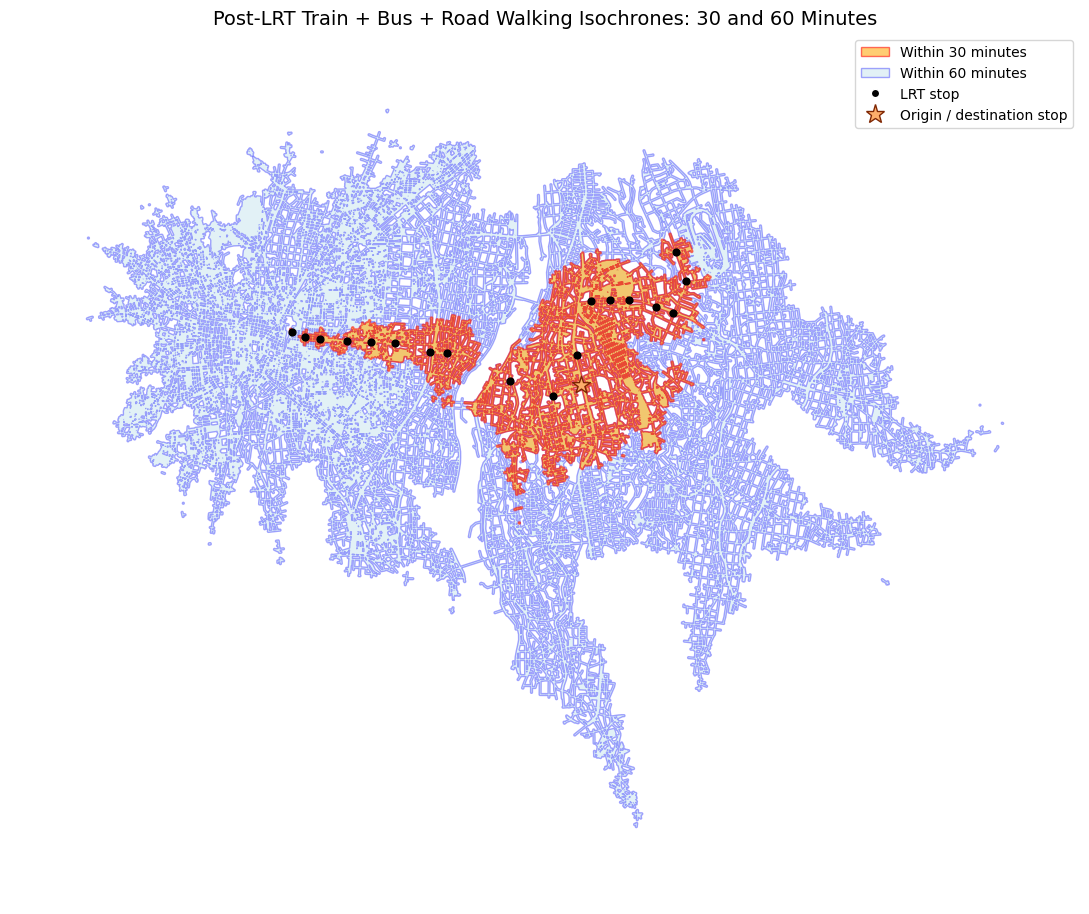

In [ ]:
# ============================================================
# Plot After-LRT with-train isochrones
# ============================================================

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

poly_30_post = post_lrt_isochrones_with_train[
    post_lrt_isochrones_with_train["time_min"] == 30
]

poly_60_post = post_lrt_isochrones_with_train[
    post_lrt_isochrones_with_train["time_min"] == 60
]

fig, ax = plt.subplots(figsize=(11, 11))

# 60-min first, then 30-min on top
poly_60_post.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    linewidth=1.0,
    alpha=0.35
)

poly_30_post.plot(
    ax=ax,
    color="orange",
    edgecolor="red",
    linewidth=1.2,
    alpha=0.55
)

# LRT stops
usable_lrt_stops.plot(
    ax=ax,
    color="black",
    markersize=24,
    label="LRT stops"
)

# Destination / origin stop
target_lrt_stop.plot(
    ax=ax,
    marker="*",
    color="#fdae6b",
    edgecolor="#7f2704",
    markersize=180,
    label="Origin / destination stop"
)

# Zoom to 60-min polygon
minx, miny, maxx, maxy = poly_60_post.total_bounds
pad = 2000
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_title(
    "Post-LRT Train + Bus + Road Walking Isochrones: 30 and 60 Minutes",
    fontsize=14
)

ax.set_axis_off()
ax.set_aspect("equal")

legend_handles = [
    Patch(facecolor="orange", edgecolor="red", alpha=0.55, label="Within 30 minutes"),
    Patch(facecolor="lightblue", edgecolor="blue", alpha=0.35, label="Within 60 minutes"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=6, label="LRT stop"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#fdae6b",
           markeredgecolor="#7f2704", markersize=14, label="Origin / destination stop"),
]

ax.legend(handles=legend_handles, loc="upper right", frameon=True)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "post_lrt_train_bus_road_walk_30_60min.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Overlay Population Mesh

In [ ]:
# ============================================================
# Prepare Before-LRT and After-LRT polygons
# ============================================================

# Before-LRT with rail
before_lrt = pre_lrt_isochrones_with_rail.copy()
before_lrt["period"] = "before_lrt"

# After-LRT with train
after_lrt = post_lrt_isochrones_with_train.copy()
after_lrt["period"] = "after_lrt"

before_lrt = before_lrt[before_lrt["time_min"].isin([30, 60])].copy()
after_lrt = after_lrt[after_lrt["time_min"].isin([30, 60])].copy()

access_polygons = pd.concat(
    [before_lrt, after_lrt],
    ignore_index=True
)

access_polygons = gpd.GeoDataFrame(
    access_polygons,
    geometry="geometry",
    crs=CRS_ANALYSIS
)

display(access_polygons[["period", "time_min", "model", "geometry"]])

,period,time_min,model,geometry
0,before_lrt,30,bus_plus_road_walking_plus_rail_unrestricted_w...,"MULTIPOLYGON (((-78778.844 -383662.127, -78779..."
1,before_lrt,60,bus_plus_road_walking_plus_rail_unrestricted_w...,"MULTIPOLYGON (((-86859.996 -384798.228, -86860..."
2,after_lrt,30,post_lrt_bus_road_walking_rail_lrt,"MULTIPOLYGON (((-82335.165 -382048.635, -82335..."
3,after_lrt,60,post_lrt_bus_road_walking_rail_lrt,"MULTIPOLYGON (((-88000.784 -384200.667, -88001..."


In [ ]:
# ============================================================
# Define area-weighted population overlay function
# ============================================================

def estimate_population_covered(mesh_gdf, polygon_gdf, pop_cols):
    mesh = mesh_gdf.copy()
    poly = polygon_gdf.copy()

    mesh["mesh_area_m2"] = mesh.geometry.area

    results = []

    for idx, row in poly.iterrows():
        period = row["period"]
        time_min = row["time_min"]

        one_poly = gpd.GeoDataFrame(
            {
                "period": [period],
                "time_min": [time_min]
            },
            geometry=[row.geometry],
            crs=CRS_ANALYSIS
        )

        clipped = gpd.overlay(mesh, one_poly, how="intersection")

        if clipped.empty:
            record = {
                "period": period,
                "time_min": time_min,
                "covered_area_km2": 0
            }
            for col in pop_cols:
                record[col + "_covered"] = 0
            results.append(record)
            continue

        clipped["intersect_area_m2"] = clipped.geometry.area
        clipped["area_share"] = clipped["intersect_area_m2"] / clipped["mesh_area_m2"]

        for col in pop_cols:
            clipped[col + "_weighted"] = clipped[col] * clipped["area_share"]

        record = {
            "period": period,
            "time_min": time_min,
            "covered_area_km2": clipped["intersect_area_m2"].sum() / 1_000_000
        }

        for col in pop_cols:
            record[col + "_covered"] = clipped[col + "_weighted"].sum()

        results.append(record)

    return pd.DataFrame(results)

In [ ]:
# ============================================================
# Estimate covered area and population
# ============================================================

pop_cols = [TOTAL_POP_COL, WORKING_POP_COL]

coverage_summary = estimate_population_covered(
    mesh_gdf=pop_mesh_tochigi,
    polygon_gdf=access_polygons,
    pop_cols=pop_cols
)

display(coverage_summary)

,period,time_min,covered_area_km2,PT00_2025_covered,PTB_2025_covered
0,before_lrt,30,7.391448,13220.638536,8135.449880
1,before_lrt,60,79.908418,202045.023059,126645.005615
2,after_lrt,30,13.572313,31853.225723,20628.926677
3,after_lrt,60,95.475889,252637.004177,156862.518238


# 10. Summary of products and results

The main products of this project are 30-minute and 60-minute accessibility polygons for the Before-LRT and After-LRT scenarios, population-overlay maps, and a summary table of changes in accessible area and covered working-age population. The maps show the accessibility areas before and after the introduction of the Utsunomiya LRT. In the After-LRT map, LRT stations are shown as black points, and the destination at Kiyohara District Civic Center is shown as a black star. The population maps also overlay the accessibility polygons with 250-meter working-age population mesh data.

The results show that the LRT substantially improved short-duration accessibility to the Kiyohara industrial area. The 30-minute accessibility area increased from 7.39 km² to 13.57 km², an increase of 6.18 km², or about 83.6%. The 60-minute accessibility area increased from 79.91 km² to 95.48 km², an increase of 15.57 km², or about 19.5%.

The population coverage results show a similar pattern. Within the 30-minute area, the covered working-age population increased from about 8,135 to 20,629 people, an increase of about 12,493 people, or about 153.6%. Within the 60-minute area, the covered working-age population increased from about 126,645 to 156,863 people, an increase of about 30,218 people, or about 23.9%.

These results are important because they suggest that the LRT improves access between population-concentrated urban areas, including central Utsunomiya, and the eastern industrial area. This supports the idea that the LRT can improve commuting accessibility and expand the population that can reasonably reach the Kiyohara industrial area by public transportation.

## Before vs After Comparison Table

In [ ]:
# ============================================================
# Calculate increase from Before-LRT to After-LRT
# ============================================================

before_summary = coverage_summary[
    coverage_summary["period"] == "before_lrt"
].copy()

after_summary = coverage_summary[
    coverage_summary["period"] == "after_lrt"
].copy()

increase_summary = after_summary.merge(
    before_summary,
    on="time_min",
    suffixes=("_after", "_before")
)

increase_summary["area_increase_km2"] = (
    increase_summary["covered_area_km2_after"]
    - increase_summary["covered_area_km2_before"]
)

increase_summary["total_pop_increase"] = (
    increase_summary[f"{TOTAL_POP_COL}_covered_after"]
    - increase_summary[f"{TOTAL_POP_COL}_covered_before"]
)

increase_summary["working_age_pop_increase"] = (
    increase_summary[f"{WORKING_POP_COL}_covered_after"]
    - increase_summary[f"{WORKING_POP_COL}_covered_before"]
)

display(
    increase_summary[
        [
            "time_min",
            "covered_area_km2_before",
            "covered_area_km2_after",
            "area_increase_km2",
            f"{TOTAL_POP_COL}_covered_before",
            f"{TOTAL_POP_COL}_covered_after",
            "total_pop_increase",
            f"{WORKING_POP_COL}_covered_before",
            f"{WORKING_POP_COL}_covered_after",
            "working_age_pop_increase"
        ]
    ]
)

,time_min,covered_area_km2_before,covered_area_km2_after,area_increase_km2,PT00_2025_covered_before,PT00_2025_covered_after,total_pop_increase,PTB_2025_covered_before,PTB_2025_covered_after,working_age_pop_increase
0,30,7.391448,13.572313,6.180865,13220.638536,31853.225723,18632.587187,8135.449880,20628.926677,12493.476796
1,60,79.908418,95.475889,15.567471,202045.023059,252637.004177,50591.981118,126645.005615,156862.518238,30217.512623


In [ ]:
# ============================================================
# Save Before vs After comparison table
# ============================================================

output_table = increase_summary[
    [
        "time_min",
        "covered_area_km2_before",
        "covered_area_km2_after",
        "area_increase_km2",
        f"{TOTAL_POP_COL}_covered_before",
        f"{TOTAL_POP_COL}_covered_after",
        "total_pop_increase",
        f"{WORKING_POP_COL}_covered_before",
        f"{WORKING_POP_COL}_covered_after",
        "working_age_pop_increase"
    ]
].copy()

csv_path = TABLE_DIR / "before_after_lrt_accessibility_summary.csv"

output_table.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(csv_path)

display(output_table)

Saved:
output/pre_lrt_multimodal/tables/before_after_lrt_accessibility_summary.csv


,time_min,covered_area_km2_before,covered_area_km2_after,area_increase_km2,PT00_2025_covered_before,PT00_2025_covered_after,total_pop_increase,PTB_2025_covered_before,PTB_2025_covered_after,working_age_pop_increase
0,30,7.391448,13.572313,6.180865,13220.638536,31853.225723,18632.587187,8135.449880,20628.926677,12493.476796
1,60,79.908418,95.475889,15.567471,202045.023059,252637.004177,50591.981118,126645.005615,156862.518238,30217.512623


## Final Maps

In [ ]:
# ============================================================
# Prepare map layers for 6 municipalities
# ============================================================

MAP_POP_COL = WORKING_POP_COL  # PTB_2025

target_city_keywords_en = "Utsunomiya|Haga|Moka|Kaminokawa|Takanezawa|Ichikai"
target_city_keywords_jp = "宇都宮|芳賀|真岡|上三川|高根沢|市貝"

study_area_6 = admin_tochigi[
    admin_tochigi[CITY_COL].astype(str).str.contains(
        target_city_keywords_en, regex=True, na=False
    )
    |
    admin_tochigi[CITY_JP_COL].astype(str).str.contains(
        target_city_keywords_jp, regex=True, na=False
    )
].copy()

study_area_6_union = study_area_6.dissolve()

pop_mesh_map = gpd.clip(pop_mesh_tochigi, study_area_6_union).copy()
rail_routes_map = gpd.clip(non_lrt_rail_routes, study_area_6_union).copy()

before_30 = before_lrt[before_lrt["time_min"] == 30].copy()
before_60 = before_lrt[before_lrt["time_min"] == 60].copy()

after_30 = after_lrt[after_lrt["time_min"] == 30].copy()
after_60 = after_lrt[after_lrt["time_min"] == 60].copy()

print("Selected municipalities:")
display(study_area_6[[PREF_COL, CITY_COL, CITY_JP_COL]].drop_duplicates())

print("Population mesh for map:", pop_mesh_map.shape)
print("Rail routes for map:", rail_routes_map.shape)

Selected municipalities:


,NAME_1,NAME_2,NL_NAME_2
1556,Tochigi,Haga,芳賀町
1557,Tochigi,Ichikai,市貝町
1559,Tochigi,Kaminokawa,上三川町
1563,Tochigi,Mōka,真岡市
1580,Tochigi,Takanezawa,高根沢町
1583,Tochigi,Utsunomiya,宇都宮市


Population mesh for map: (8244, 344)
Rail routes for map: (17, 12)


In [ ]:
# ============================================================
# Define map plotting function
# Greys + Quantile legend + softened darkest color
# ============================================================

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# Custom grey colormap:
# light grey -> dark grey, but not pure black
soft_greys = LinearSegmentedColormap.from_list(
    "soft_greys",
    ["#f7f7f7", "#d9d9d9", "#bdbdbd", "#737373", "#3a3a3a"]
)

def plot_accessibility_map_6muni(
    poly_30,
    poly_60,
    title,
    output_path,
    show_lrt=False
):
    fig, ax = plt.subplots(figsize=(11, 11))

    # Population mesh: Quantile classification
    pop_mesh_map.plot(
        ax=ax,
        column=MAP_POP_COL,
        cmap=soft_greys,
        scheme="Quantiles",
        k=5,
        linewidth=0,
        alpha=0.45,
        legend=True,
        legend_kwds={
            "title": "Working-age population\nPTB_2025",
            "loc": "lower left",
            "frameon": True
        }
    )

    # Conventional rail
    if not rail_routes_map.empty:
        rail_routes_map.plot(
            ax=ax,
            color="dimgray",
            linewidth=1.1,
            linestyle="--",
            alpha=0.75
        )

    # 60 min
    poly_60.plot(
        ax=ax,
        color="cornflowerblue",
        alpha=0.25,
        edgecolor="blue",
        linewidth=1.2
    )

    # 30 min
    poly_30.plot(
        ax=ax,
        color="orange",
        alpha=0.55,
        edgecolor="red",
        linewidth=1.3
    )

    # LRT stops: After only
    if show_lrt:
        usable_lrt_stops.plot(
            ax=ax,
            color="black",
            markersize=22,
            alpha=0.95
        )

    # Destination
    origin.plot(
        ax=ax,
        marker="*",
        color="black",
        markersize=190
    )

    # Municipal boundaries
    study_area_6.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8
    )

    minx, miny, maxx, maxy = study_area_6_union.total_bounds
    pad = 1500
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect("equal")

    legend_handles = [
        Patch(facecolor="orange", edgecolor="red", alpha=0.55, label="Within 30 minutes"),
        Patch(facecolor="cornflowerblue", edgecolor="blue", alpha=0.25, label="Within 60 minutes"),
        Line2D([0], [0], color="dimgray", linestyle="--", linewidth=1.4, label="Conventional rail"),
        Line2D([0], [0], color="black", linewidth=0.9, label="Municipal boundary"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="black",
               markersize=14, label="Destination")
    ]

    if show_lrt:
        legend_handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor="black",
                   markersize=7, label="LRT stops")
        )

    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved map to: {output_path}")

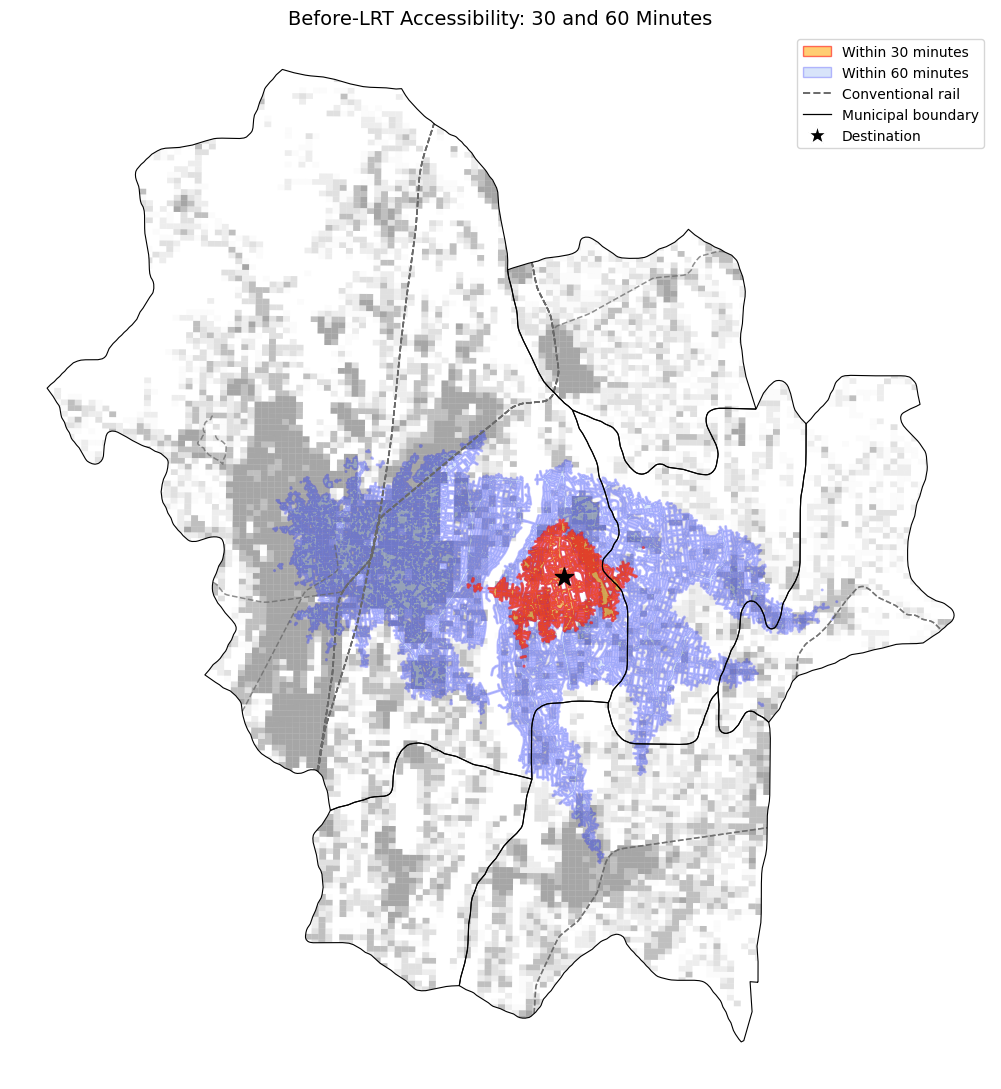

Saved map to: output/pre_lrt_multimodal/figures/before_lrt_6muni_30_60_population_mesh.png


In [ ]:
# ============================================================
# Plot Before-LRT map
# ============================================================

before_map_path = FIG_DIR / "before_lrt_6muni_30_60_population_mesh.png"

plot_accessibility_map_6muni(
    poly_30=before_30,
    poly_60=before_60,
    title="Before-LRT Accessibility: 30 and 60 Minutes",
    output_path=before_map_path,
    show_lrt=False
)

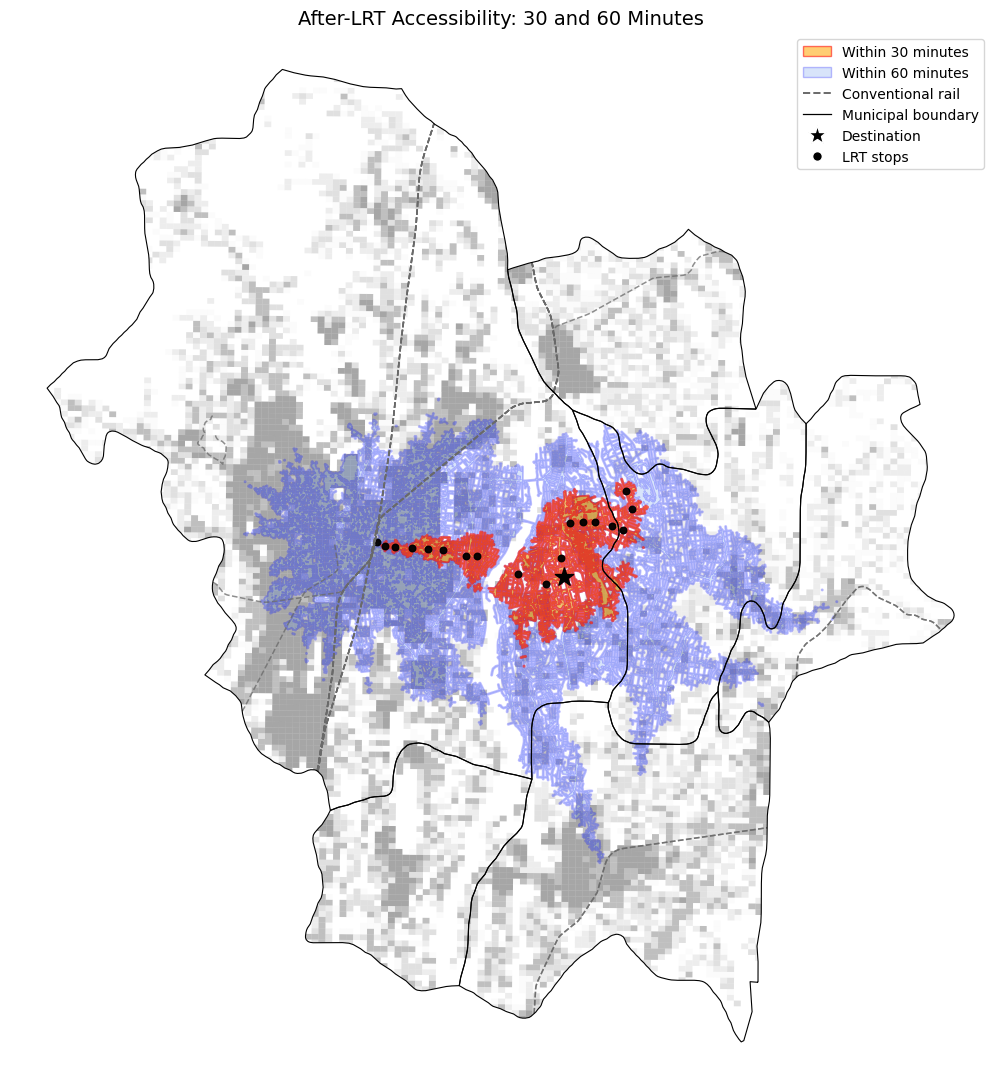

Saved map to: output/pre_lrt_multimodal/figures/after_lrt_6muni_30_60_population_mesh.png


In [ ]:
# ============================================================
# Plot After-LRT map
# ============================================================

after_map_path = FIG_DIR / "after_lrt_6muni_30_60_population_mesh.png"

plot_accessibility_map_6muni(
    poly_30=after_30,
    poly_60=after_60,
    title="After-LRT Accessibility: 30 and 60 Minutes",
    output_path=after_map_path,
    show_lrt=True
)

# 11. Discussion

The findings are consistent with the literature and policy discussion reviewed in Section 4. Prior studies and policy documents emphasize that LRT investment is most effective when it improves corridor-based accessibility, connects with existing bus and rail systems, and supports compact-city planning rather than functioning as an isolated rail project. Our results support this view. The Utsunomiya LRT appears to fill an important east-west transit gap between central Utsunomiya and the Kiyohara industrial area, where public transportation access had previously depended mainly on bus and road-based travel.

The most important contribution of this analysis is that it quantifies accessibility change spatially, rather than only describing ridership or route length. The 30-minute results show that the LRT brought population-dense areas around the Utsunomiya Station corridor into a more realistic public-transit commute range. This improves our understanding of the LRT’s policy value: it is not only a transportation infrastructure project, but also a labor-market accessibility intervention.

The costs and benefits of the LRT are likely to differ across stakeholder groups. Working-age residents may benefit from improved access to jobs, while employers in Kiyohara Industrial Park may benefit from a larger potential labor pool. The municipality may benefit from progress toward compact-city and reduced car-dependence goals. However, corridor residents and businesses may also face trade-offs such as land value increases, rent pressure, construction impacts, or road-space reallocation. Car users may benefit indirectly if congestion is reduced, but this depends on whether improved accessibility actually leads to a shift from cars to public transit.

These impacts may also evolve over time. In the short run, the main measurable outcome is improved potential accessibility, as captured in this analysis. In the medium run, the benefits may depend on bus network reorganization, transfer convenience, and changes in commuting behavior. In the long run, the LRT may influence land use, residential location choices, land prices, and business activity along the corridor. Therefore, the LRT should be evaluated not only by aggregate accessibility gains, but also by how those gains and costs are distributed among workers, residents, firms, road users, and the local government over time.

Several methodological trade-offs were necessary. First, we used EPSG:6678, a projected CRS appropriate for distance-based analysis in this region of Japan, because the analysis depends on distances, buffers, and travel-time calculations. Second, we generated road-based isochrone polygons by buffering reachable road edges, rather than using simple circular buffers. This better represents actual movement through the road and transit network, although the resulting polygons depend on the chosen corridor-buffer width. Third, we used fixed travel speeds and waiting-time penalties for walking, bus, rail, and LRT. This made the model reproducible and computationally feasible, but it cannot capture full timetable variation, transfer coordination, or peak-hour delays.

Performance was also a constraint. Building a multimodal network from road, bus, rail, and LRT shapefiles required clipping the analysis area and checking snap distances between stops, roads, and route nodes. We also chose not to use machine learning because the research question is better answered through network-based accessibility analysis than prediction. Overall, the analysis provides a transparent spatial estimate of accessibility change, but it should be interpreted as potential access rather than actual travel behavior.


# 12. Conclusions and future work

This project partially answers the initial research question: how much did the Utsunomiya LRT improve public transportation accessibility to industrial zones? The analysis shows that the LRT meaningfully improved accessibility to the Kiyohara Industrial Park area, especially within the 30-minute catchment. The improvement is visible both geographically and demographically: the accessible area expanded toward central Utsunomiya, and the covered working-age population increased substantially. From a GIS-based accessibility perspective, the LRT can therefore be understood as supporting the city’s policy goal of improving public transportation access to the eastern industrial area.

However, the project does not completely answer all policy questions related to the LRT. The results measure potential accessibility, not actual ridership, commuting behavior, car-to-transit mode shift, or congestion reduction. In addition, the analysis is a descriptive before-and-after comparison, so it cannot fully isolate the causal effect of the LRT from other changes in population distribution, bus services, land use, or urban development.

Future work should address these gaps in several ways. First, if data are available, a Cost-Benefit Analysis would be useful for translating accessibility gains into economic benefits and comparing them with construction and operating costs. This would require data on ridership, value of travel time, project costs, operating costs, and possibly congestion reduction. Data availability may be a major limitation.

Second, a stronger causal design could be developed using Difference-in-Differences with comparable control corridors that did not receive LRT service. Third, the routing model could be improved using GTFS or detailed timetable data, allowing more realistic estimates of waiting times, transfers, and peak-hour service frequency. Fourth, the same framework could be extended to evaluate the planned westward extension, commercial accessibility to Utsunomiya Station, or accessibility impacts in other Japanese regional cities considering compact-city and transit-oriented development strategies.

Future work should also broaden the outcome measures beyond accessibility. Economically, the analysis could examine whether improved access affects employment opportunities, business activity near stations, land values, or municipal tax revenues. Environmentally, future research could estimate reductions in vehicle-kilometers traveled, CO₂ emissions, and local air pollution if the LRT induces a shift from private cars to public transit. From an equity perspective, additional analysis could examine whether the system improves accessibility for elderly residents, students, low-income households, or households without cars, not only for working-age residents.

These extensions would help evaluate the LRT as a long-term urban policy intervention rather than only as a transportation project. In particular, combining accessibility analysis with ridership data, commuting-flow data, land price data, and environmental indicators would provide a more complete picture of who benefits, who bears costs, and how those impacts change over time. The expected users of this work are transportation policymakers, city planners, and local governments. The method provides a reproducible way to evaluate whether transit investments improve access to employment centers and which populations are likely to benefit.
